# Accident Severity Prediction

# Index:

[1. Importing Libraries](#Import)

[2. Loading Dataset](#dataset)

[3. Information of the data](#log)

[4. Preprocessing (cleaning)](#datacleaning)

[5.Exploratory Data Analysis (EDA)](#EDA)

   [5.1 Univariate Analysis:](#)

     i. Distribution of people by Gender
     ii. Distribution of people by Person_type
     iii. Distribution of people by Age group

   [5.2 Bivariate Analysis](#).

     i. Distribution of Pedestrian Location and Pedestrian action over Severity
     ii. Distribution of Contributing factors (both 1 & 2) over Severity

[6 Handling Missing data (Imputation)](#).

     6.1 Filling with mode
     6.2 Filling with RandomForest


[7. Model Evaluation](#)

      7.1 RandomForest Classifier
      7.2 AdaBoost
      7.3 XGBoost
      7.4 XGBoost after SMOTE

[8. Streamlit Application](#)

[9. Conclusion](#)

1. Importing Libraries


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

import xgboost as xgb

import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE

from sklearn.metrics import roc_curve, auc


import warnings
warnings.filterwarnings('ignore')

2. Loading Dataset

In [ ]:
# Reload the CSV with error handling for malformed lines
# 'on_bad_lines="skip"' tells pandas to skip rows that cause parsing errors
docs = pd.read_csv('/content/Vehicle Collision(in).csv', on_bad_lines='skip')

3. Information of the data

In [ ]:
docs.shape

(230660, 21)

In [ ]:
docs.head()

,UNIQUE_ID,COLLISION_ID,CRASH_DATE,CRASH_TIME,PERSON_ID,PERSON_TYPE,PERSON_INJURY,VEHICLE_ID,PERSON_AGE,EJECTION,...,BODILY_INJURY,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT,PED_LOCATION,PED_ACTION,COMPLAINT,PED_ROLE,CONTRIBUTING_FACTOR_1,CONTRIBUTING_FACTOR_2,PERSON_SEX
0,10253606,4230743.0,10/24/2019,19:15,84bcb3a7-d201-4c61-9e30-fe29268c1074,Occupant,Injured,19143343.0,27.0,Not Ejected,...,Back,Driver,Lap Belt & Harness,NaN,NaN,Complaint of Pain or Nausea,Driver,NaN,NaN,M
1,10248708,4229547.0,10/26/2019,1:15,a8904763-2870-42f3-865c-b53d8e5156e2,Pedestrian,Injured,NaN,24.0,NaN,...,Shoulder - Upper Arm,NaN,NaN,Pedestrian/Bicyclist/Other Pedestrian at Inter...,Crossing With Signal,None Visible,Pedestrian,Unspecified,Unspecified,F
2,10254556,4230715.0,10/26/2019,8:50,1a085543-ae9d-4a69-8cd0-fb7b33380a8b,Bicyclist,Injured,19143832.0,42.0,Not Ejected,...,Knee-Lower Leg Foot,Driver,Unknown,NaN,NaN,None Visible,Driver,NaN,NaN,M
3,10250834,4230376.0,10/26/2019,19:40,f58fc41f-497e-4f30-bf49-a9a80adec8b2,Bicyclist,Injured,19141949.0,36.0,Not Ejected,...,Back,Driver,NaN,NaN,NaN,Internal,Driver,NaN,NaN,M
4,10252474,4229773.0,10/26/2019,16:50,4bf13d12-8d7a-4cb0-997f-dd6a8b1adca6,Occupant,Injured,19142773.0,50.0,Not Ejected,...,Head,"Front passenger, if two or more persons, inclu...",Lap Belt & Harness,NaN,NaN,Complaint of Pain or Nausea,Passenger,NaN,NaN,F


In [130]:
docs1=docs.drop(index=[230656,230657,230658,230659],axis=0)
driv=docs1.copy()
driv.shape


(230656, 21)

In [ ]:
driv['PERSON_INJURY'].value_counts()

,count
PERSON_INJURY,
Injured,229633
Killed,1023


In [ ]:
missing_counts = driv.isnull().sum()
print("Missing values per column:")
display(missing_counts[missing_counts > 0].sort_values(ascending=False))

Missing values per column:


,0
CONTRIBUTING_FACTOR_2,205473
CONTRIBUTING_FACTOR_1,205448
PED_ACTION,204426
PED_LOCATION,204364
SAFETY_EQUIPMENT,140536
EJECTION,127869
POSITION_IN_VEHICLE,127750
PERSON_SEX,103764
EMOTIONAL_STATUS,103738
BODILY_INJURY,103697


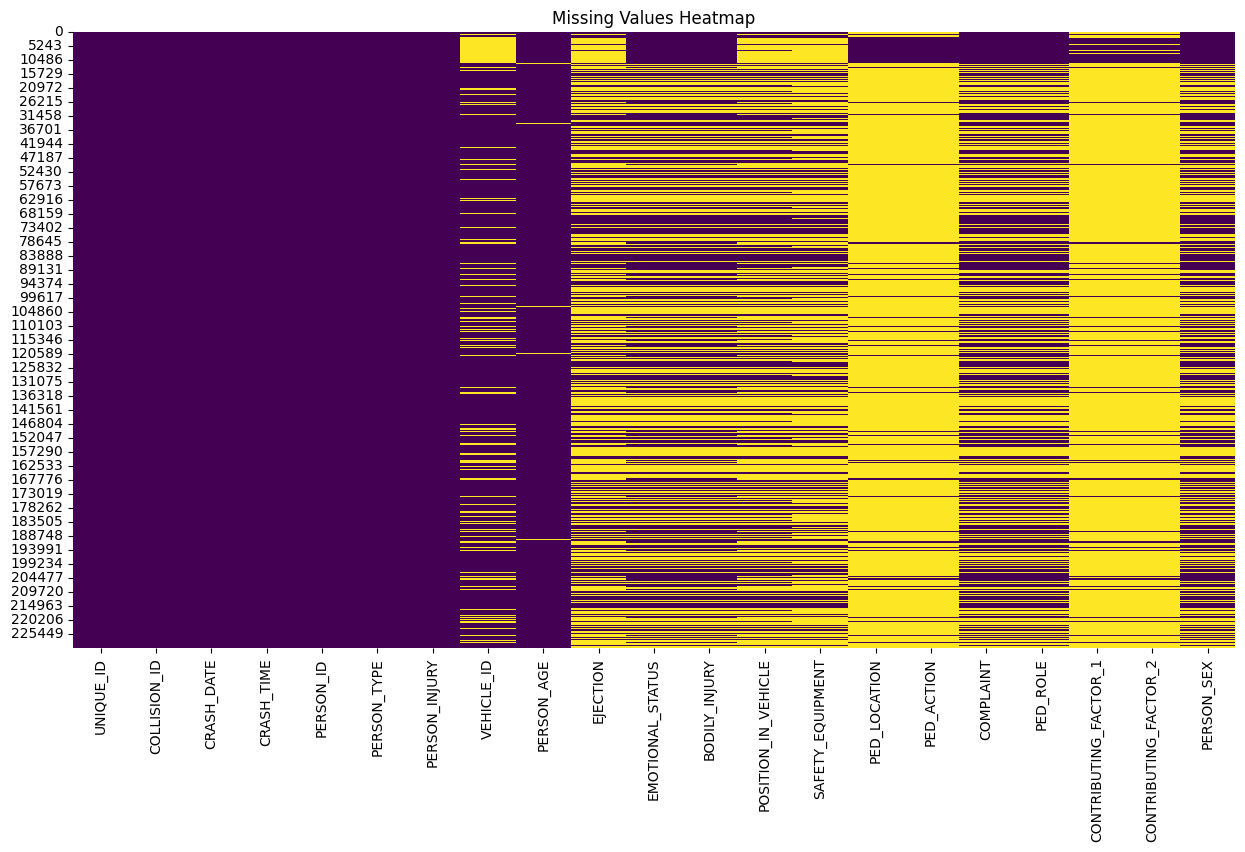

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(driv.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
pd.set_option('display.max_columns',None)

In [ ]:
driv.shape

(230656, 24)

# 4. Preprocessing (cleaning)

Conversion of Date and Time format into separate numerical columns:

In [131]:
# Combine 'CRASH_DATE' and 'CRASH_TIME' into a new datetime column
driv['CRASH_DATE_TIME'] = pd.to_datetime(driv['CRASH_DATE'] + ' ' + driv['CRASH_TIME'])

# Extract various date and time components
driv['CRASH_YEAR'] = driv['CRASH_DATE_TIME'].dt.year
driv['CRASH_MONTH'] = driv['CRASH_DATE_TIME'].dt.month
driv['CRASH_DAY'] = driv['CRASH_DATE_TIME'].dt.day
driv['CRASH_DAY_OF_WEEK'] = driv['CRASH_DATE_TIME'].dt.dayofweek # Monday=0, Sunday=6
driv['CRASH_HOUR'] = driv['CRASH_DATE_TIME'].dt.hour
#driv['CRASH_MINUTE'] = driv['CRASH_DATE_TIME'].dt.minute # Extract minutes

# Display the new columns along with the original ones for verification
display(driv[['CRASH_DATE', 'CRASH_TIME', 'CRASH_DATE_TIME', 'CRASH_YEAR', 'CRASH_MONTH', 'CRASH_DAY', 'CRASH_DAY_OF_WEEK', 'CRASH_HOUR']].head())

driv=driv.drop(columns=['CRASH_DATE','CRASH_TIME','CRASH_DATE_TIME'],axis=1)

driv.shape

,CRASH_DATE,CRASH_TIME,CRASH_DATE_TIME,CRASH_YEAR,CRASH_MONTH,CRASH_DAY,CRASH_DAY_OF_WEEK,CRASH_HOUR
0,10/24/2019,19:15,2019-10-24 19:15:00,2019,10,24,3,19
1,10/26/2019,1:15,2019-10-26 01:15:00,2019,10,26,5,1
2,10/26/2019,8:50,2019-10-26 08:50:00,2019,10,26,5,8
3,10/26/2019,19:40,2019-10-26 19:40:00,2019,10,26,5,19
4,10/26/2019,16:50,2019-10-26 16:50:00,2019,10,26,5,16


(230656, 24)

In [ ]:
driv.sample(n=5)

,UNIQUE_ID,COLLISION_ID,PERSON_ID,PERSON_TYPE,PERSON_INJURY,VEHICLE_ID,PERSON_AGE,EJECTION,EMOTIONAL_STATUS,BODILY_INJURY,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT,PED_LOCATION,PED_ACTION,COMPLAINT,PED_ROLE,CONTRIBUTING_FACTOR_1,CONTRIBUTING_FACTOR_2,PERSON_SEX,CRASH_YEAR,CRASH_MONTH,CRASH_DAY,CRASH_DAY_OF_WEEK,CRASH_HOUR
91241,5772191,3416378.0,338396,Occupant,0,16956435.0,21,Does Not Apply,Conscious,Unknown,Driver,Lap Belt & Harness,NaN,NaN,Unknown,Driver,nan,nan,F,2016,3,31,3,7
119551,8962085,4057941.0,83084919-084d-4632-b433-9802699ac404,Occupant,0,18503753.0,44,Not Ejected,Unknown,Head,Unknown,Unknown,NaN,NaN,Unknown,Passenger,nan,nan,F,2019,1,17,3,18
204479,1825964,179222.0,1,Occupant,0,11919052.0,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,NaN,2014,2,18,1,20
12704,2233588,3142813.0,1,Occupant,0,14516100.0,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,NaN,2014,12,24,2,21
222486,2258876,3237265.0,1,Pedestrian,0,NaN,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,nan,NaN,2015,6,9,1,15


Conversion of Person Age (float) to (int):

In [ ]:
driv['PERSON_AGE']=driv['PERSON_AGE'].astype('Int64')



Filling missing data of Person Age with Median Value:

Replaced erroneous age values and imputed missing values with median age: 33.0
Descriptive statistics after cleaning and imputation:


,PERSON_AGE
count,230656.0
mean,36.074674
std,57.477597
min,-980.0
25%,23.0
50%,33.0
75%,49.0
max,7202.0


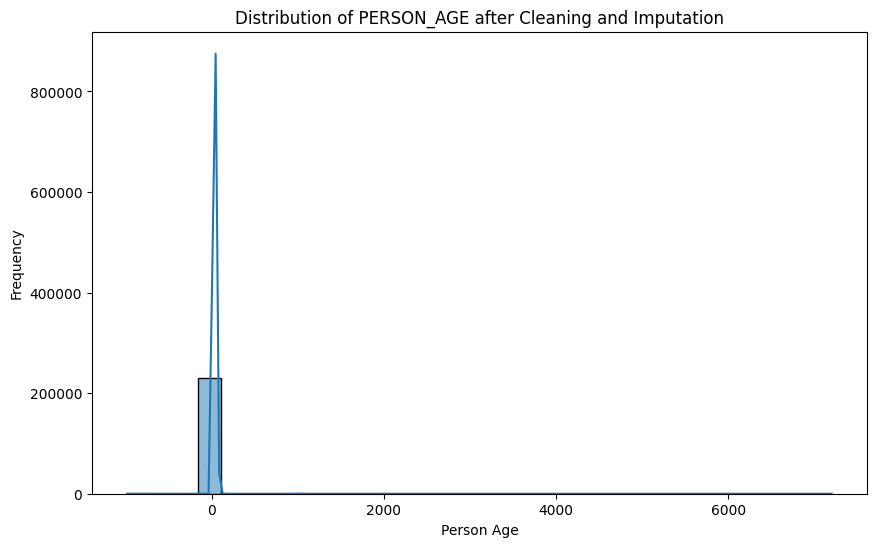

In [ ]:
# Replace erroneous age values (-997 and 9999) with NaN
driv['PERSON_AGE'] = driv['PERSON_AGE'].replace([-997, 9999], None)

# Calculate the median age, excluding NaN values
median_age = driv['PERSON_AGE'].median()

# Fill missing PERSON_AGE values with the calculated median
driv['PERSON_AGE'] = driv['PERSON_AGE'].fillna(median_age)

# Convert PERSON_AGE to nullable integer type (Int64) to handle potential NaNs if any remained, or just int if confident no NaNs
driv['PERSON_AGE'] = driv['PERSON_AGE'].astype('Int64')

print(f"Replaced erroneous age values and imputed missing values with median age: {median_age}")
print("Descriptive statistics after cleaning and imputation:")
display(driv['PERSON_AGE'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(driv['PERSON_AGE'].dropna(), bins=30, kde=True)
plt.title('Distribution of PERSON_AGE after Cleaning and Imputation')
plt.xlabel('Person Age')
plt.ylabel('Frequency')
plt.show()

Filling Contributing Factors: Unspecified item with None:

In [ ]:
driv['CONTRIBUTING_FACTOR_1']=driv['CONTRIBUTING_FACTOR_1'].replace('Unspecified',None)
driv['CONTRIBUTING_FACTOR_2']=driv['CONTRIBUTING_FACTOR_2'].replace('Unspecified',None)



Applying Label Encoding to the Target Variable:

In [ ]:
En=LabelEncoder()
driv['PERSON_INJURY']=driv['PERSON_INJURY'].fillna('Unknown')
driv['PERSON_INJURY']=En.fit_transform(driv['PERSON_INJURY'])

# 5.Exploratory Data Analysis (EDA)


5.1 Univariate Analysis:

i. Distribution of person involved in accident, by Gender:

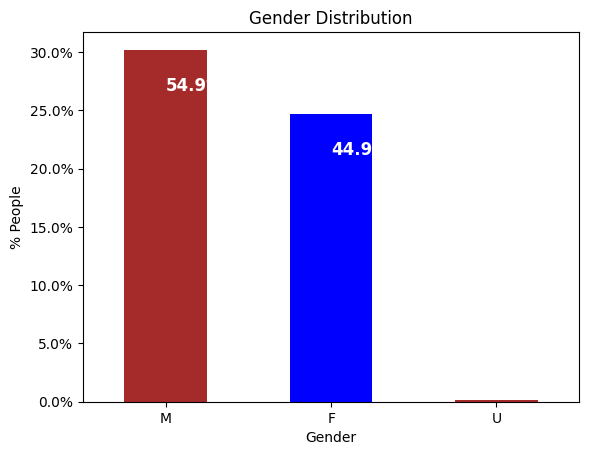

In [ ]:
colors=['brown','blue']
gender_counts=driv['PERSON_SEX'].value_counts()
ax= (gender_counts*100/len(driv)).plot(
    kind='bar',
    stacked='True',
    rot=0,
    color=colors
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Gender')
ax.set_ylabel('% People')
ax.set_title('Gender Distribution')
total=gender_counts.sum()
for bar, count in zip(ax.patches, gender_counts):
  percentage=count/total*100
  ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 3.5,
     f'{percentage:.1f}%',
          fontsize=12,
          color='white',
          weight='bold'
  )
plt.show()

ii. Distribution of person involved in accident, by person type:

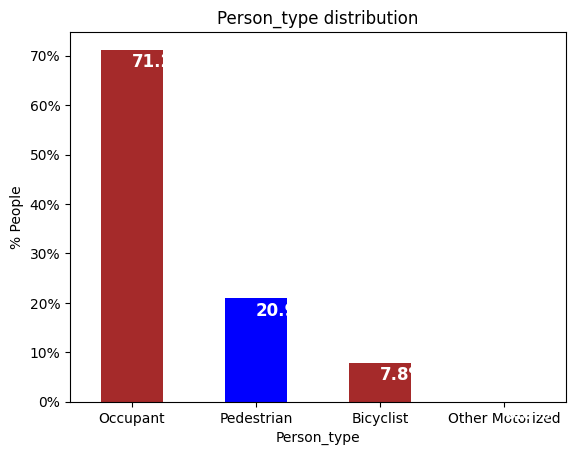

In [ ]:
colors=['brown','blue']
gender_counts=driv['PERSON_TYPE'].value_counts()
ax= (gender_counts*100/len(driv)).plot(
    kind='bar',
    stacked='True',
    rot=0,
    color=colors
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Person_type')
ax.set_ylabel('% People')
ax.set_title('Person_type distribution')
total=gender_counts.sum()
for bar, count in zip(ax.patches, gender_counts):
  percentage=count/total*100
  ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 3.5,
     f'{percentage:.1f}%',
          fontsize=12,
          color='white',
          weight='bold'
  )
plt.show()

iii. Distribution of person involved in accident, by person age:

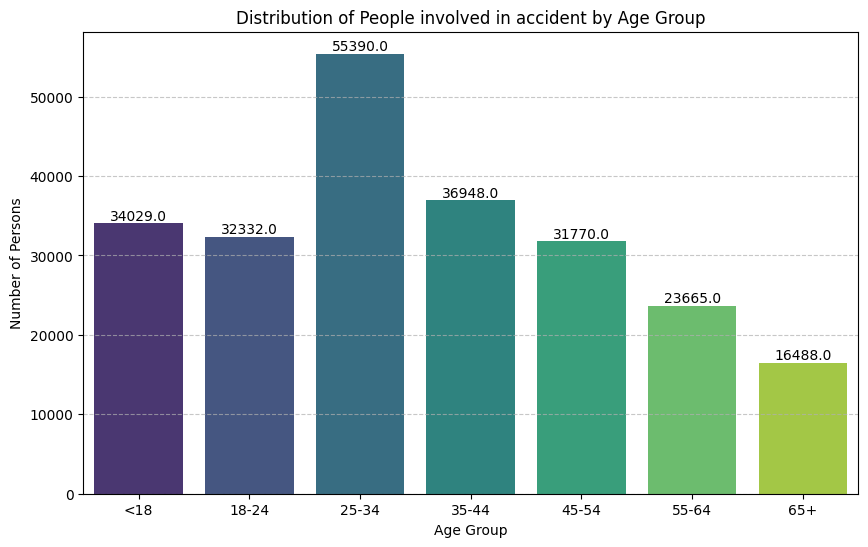

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define age bins and labels
age_bins = [0, 18, 25, 35, 45, 55, 65, driv['PERSON_AGE'].max() + 1]
age_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

# Create a new column with age groups
driv['AgeGroup'] = pd.cut(driv['PERSON_AGE'], bins=age_bins, labels=age_labels, right=False)

# Count customers in each age group
age_group_counts = driv['AgeGroup'].value_counts().sort_index()

# Plot the bar graph
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='viridis')
plt.title('Distribution of People involved in accident by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Persons')
plt.grid(axis='y', linestyle='--', alpha=0.7)
total = age_group_counts.sum()
for bar in ax.patches:
    height = bar.get_height()
    percentage = (height / total) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:}', ha='center', va='bottom')

plt.show()

In [ ]:
driv.drop(columns=['AgeGroup'],axis=1,inplace=True)

5.2 Bivariate Analysis.

Simplifying Dataset (I): (Removing some features)

In [ ]:
recordsH=driv[driv['CONTRIBUTING_FACTOR_1'].notna()]

In [ ]:
recordsH.drop(columns=['VEHICLE_ID','EJECTION','POSITION_IN_VEHICLE','SAFETY_EQUIPMENT','UNIQUE_ID','COLLISION_ID','PERSON_ID'],axis=1,inplace=True)

In [ ]:
recordsH.shape

(7989, 17)

This new simplified datset (I): (recordsH) will be used for Safety Campaign Awareness:

In [ ]:
recordsH['PERSON_TYPE'].value_counts()

,count
PERSON_TYPE,
Pedestrian,7827
Occupant,162


In [ ]:
recordsH.sample(n=10)

,PERSON_TYPE,PERSON_INJURY,PERSON_AGE,EMOTIONAL_STATUS,BODILY_INJURY,PED_LOCATION,PED_ACTION,COMPLAINT,PED_ROLE,CONTRIBUTING_FACTOR_1,PERSON_SEX,CRASH_YEAR,CRASH_MONTH,CRASH_DAY,CRASH_DAY_OF_WEEK,CRASH_HOUR
215590,Pedestrian,0,83,Conscious,Elbow-Lower-Arm-Hand,Pedestrian/Bicyclist/Other Pedestrian Not at I...,"Crossing, No Signal, or Crosswalk",Complaint of Pain,Pedestrian,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,M,2017,9,15,4,8
7149,Pedestrian,0,31,Conscious,Face,Pedestrian/Bicyclist/Other Pedestrian Not at I...,"Crossing, No Signal, or Crosswalk",Minor Bleeding,Pedestrian,Cell Phone (hand-Held),F,2016,8,17,2,0
79364,Occupant,0,30,Conscious,Elbow-Lower-Arm-Hand,Pedestrian/Bicyclist/Other Pedestrian at Inter...,Unknown,Abrasion,Other,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,M,2020,6,23,1,12
53768,Pedestrian,0,8,Conscious,Elbow-Lower-Arm-Hand,Pedestrian/Bicyclist/Other Pedestrian Not at I...,"Crossing, No Signal, or Crosswalk",Abrasion,Pedestrian,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,M,2017,7,24,0,17
83099,Pedestrian,0,63,Conscious,Knee-Lower Leg Foot,NaN,NaN,Complaint of Pain,Pedestrian,Driver Inattention/Distraction,M,2017,8,12,5,22
3227,Pedestrian,0,51,Conscious,Back,Pedestrian/Bicyclist/Other Pedestrian Not at I...,Unknown,Complaint of Pain,Pedestrian,View Obstructed/Limited,F,2016,6,8,2,13
28473,Pedestrian,0,28,Conscious,Knee-Lower Leg Foot,Pedestrian/Bicyclist/Other Pedestrian at Inter...,Working in Roadway,Complaint of Pain,Pedestrian,Failure to Yield Right-of-Way,M,2017,10,29,6,1
4580,Pedestrian,0,41,Conscious,Knee-Lower Leg Foot,Pedestrian/Bicyclist/Other Pedestrian Not at I...,"Crossing, No Signal, or Crosswalk",Minor Bleeding,Pedestrian,Alcohol Involvement,M,2016,9,29,3,8
2651,Pedestrian,0,33,Conscious,Head,Pedestrian/Bicyclist/Other Pedestrian Not at I...,Does Not Apply,Complaint of Pain,Pedestrian,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,F,2016,5,16,0,8
112114,Pedestrian,0,44,Conscious,Back,Pedestrian/Bicyclist/Other Pedestrian Not at I...,"Crossing, No Signal, or Crosswalk",Complaint of Pain,Pedestrian,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,M,2017,5,6,5,20


In [ ]:
recordsH.drop(columns=['CONTRIBUTING_FACTOR_2'],axis=1,inplace=True)

In [ ]:
recordsH.shape

(7989, 16)

In [ ]:
recordsH['PERSON_INJURY'].value_counts()

,count
PERSON_INJURY,
0,7825
1,164


Simplifying the X_lables:

In [ ]:
recordsH['PED_LOCATION']=recordsH['PED_LOCATION'].replace('Pedestrian/Bicyclist/Other Pedestrian Not at Intersection','Not at Intersection')
recordsH['PED_LOCATION']=recordsH['PED_LOCATION'].replace('Pedestrian/Bicyclist/Other Pedestrian at Intersection','At Intersection')

 i: Distribution of Pedestrian Location and Pedestrian action over Severity


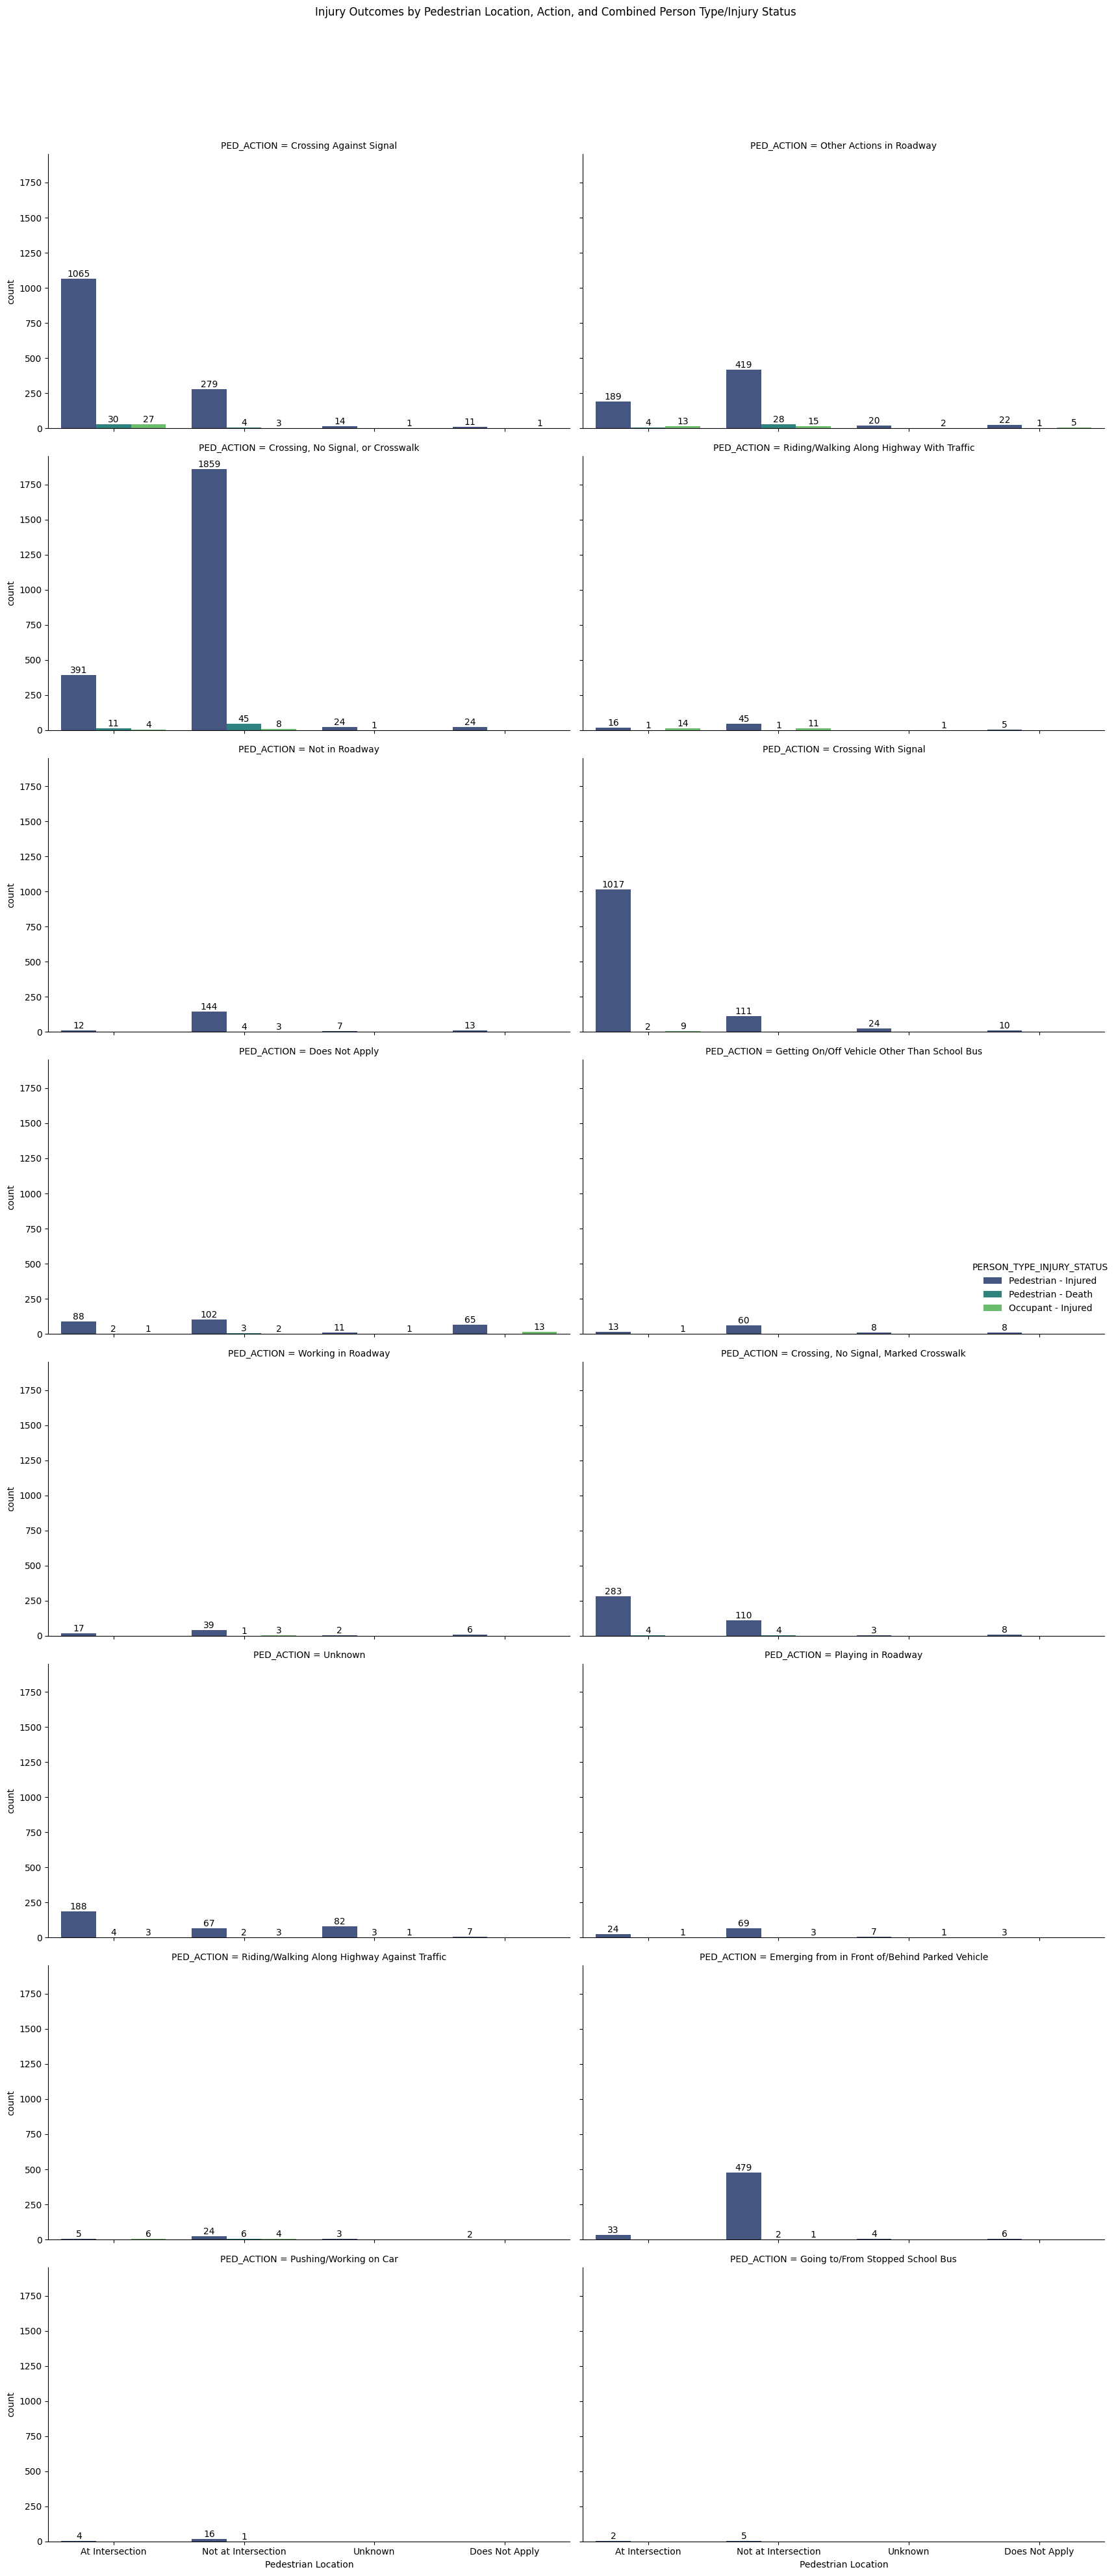

In [ ]:
# Use existing string values from recordsH['PERSON_TYPE'] for PERSON_TYPE_LABEL
recordsH['PERSON_TYPE_LABEL'] = recordsH['PERSON_TYPE']

# Map numerical PERSON_INJURY back to descriptive labels
injury_status_map = {0: 'Injured', 1: 'Death'}
recordsH['PERSON_INJURY_STATUS'] = recordsH['PERSON_INJURY'].map(injury_status_map)

# Create a combined category for hue
recordsH['PERSON_TYPE_INJURY_STATUS'] = recordsH['PERSON_TYPE_LABEL'] + ' - ' + recordsH['PERSON_INJURY_STATUS']

# Create a countplot to show the relationship between PED_LOCATION, PED_ACTION, and the combined category
g = sns.catplot(
    data=recordsH,
    x='PED_LOCATION',
    hue='PERSON_TYPE_INJURY_STATUS', # Use the combined category for color
    col='PED_ACTION', # Create separate plots for each PED_ACTION
    kind='count', # Bar plot of counts
    col_wrap=2, # Wrap columns for better layout
    height=5,
    aspect=1.5,
    palette='viridis' # Use a color palette
)

# Add numbers above the bars and set x-axis labels
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%d') # Use fmt='%d' for integer counts
    ax.set_xlabel('Pedestrian Location') # Set x-axis label for each subplot

plt.suptitle('Injury Outcomes by Pedestrian Location, Action, and Combined Person Type/Injury Status', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

ii: Distribution of Contributing factors (both 1 & 2) over Severity

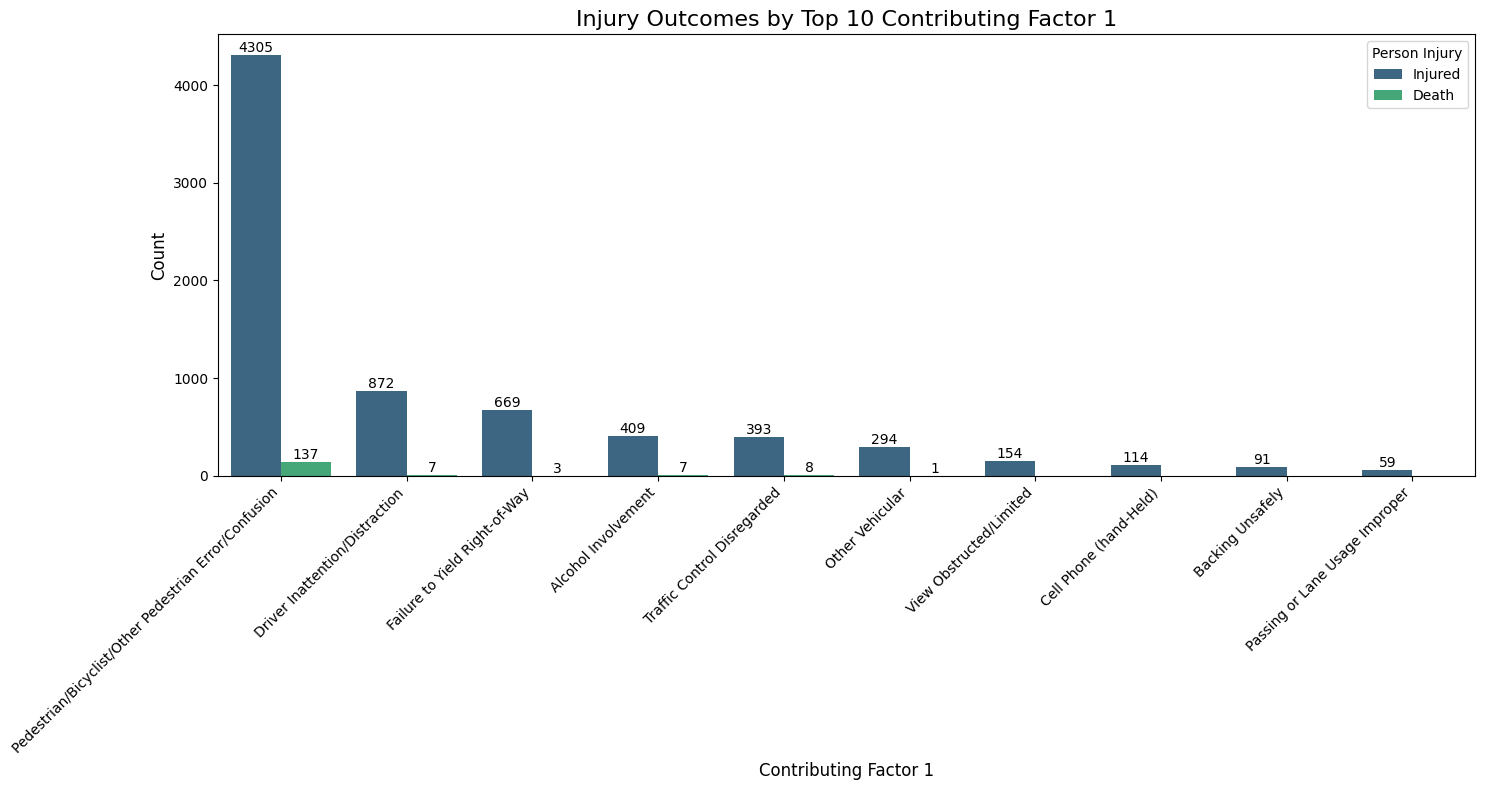

In [ ]:
# Get the top N contributing factors for better visualization
top_n_factors = recordsH['CONTRIBUTING_FACTOR_1'].value_counts().head(10).index.tolist()

# Filter the DataFrame to include only these top factors
df_filtered = recordsH[recordsH['CONTRIBUTING_FACTOR_1'].isin(top_n_factors)]

plt.figure(figsize=(15, 8))
g = sns.countplot(
    data=df_filtered,
    x='CONTRIBUTING_FACTOR_1',
    hue='PERSON_INJURY', # 0: Not Injured, 1: Injured
    palette='viridis',
    order=top_n_factors # Ensure order based on overall frequency
)

# Add numbers above the bars
for container in g.containers:
    g.bar_label(container, fmt='%d')

plt.title('Injury Outcomes by Top 10 Contributing Factor 1', fontsize=16)
plt.xlabel('Contributing Factor 1', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels for readability
plt.yticks(fontsize=10)
plt.legend(title='Person Injury', labels=['Injured', 'Death'])
plt.tight_layout()
plt.show()

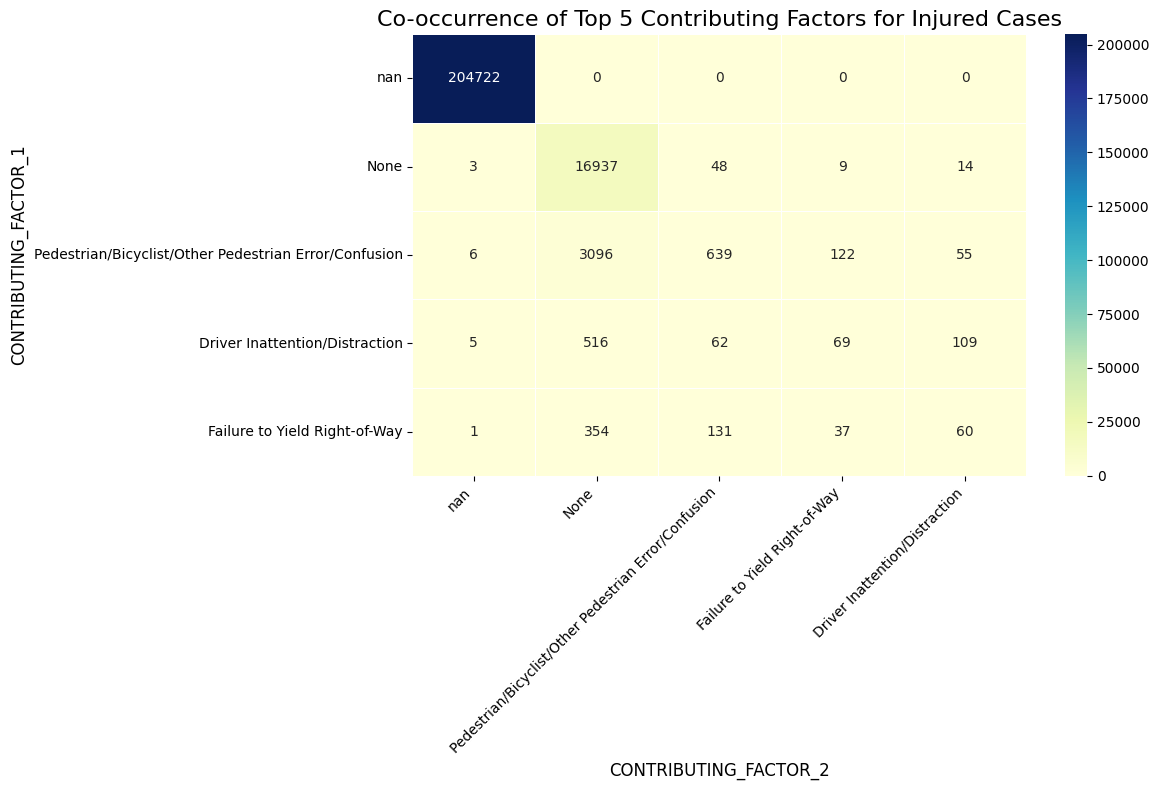

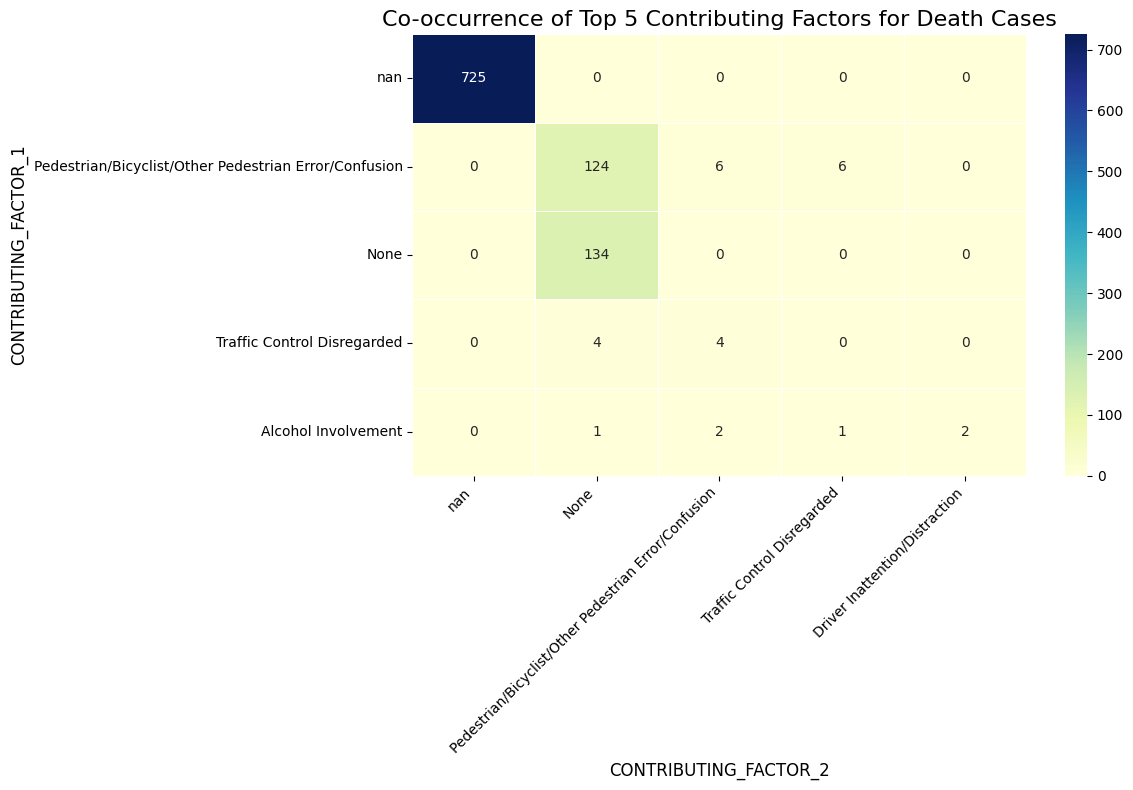

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'CONTRIBUTING_FACTOR_1' and 'CONTRIBUTING_FACTOR_2' are strings and handle NaNs
driv['CONTRIBUTING_FACTOR_1'] = driv['CONTRIBUTING_FACTOR_1'].astype(str).fillna('Unknown')
driv['CONTRIBUTING_FACTOR_2'] = driv['CONTRIBUTING_FACTOR_2'].astype(str).fillna('Unknown')

# Separate data for Injured and Death cases
df_injured = driv[driv['PERSON_INJURY'] == 0]
df_death = driv[driv['PERSON_INJURY'] == 1]

def generate_contributing_factors_heatmap(df, title_suffix):
    """
    Generates a heatmap for co-occurrence counts of top 5 CONTRIBUTING_FACTOR_1 and 2.
    """
    # Calculate co-occurrence counts
    co_occurrence_counts = df.groupby(['CONTRIBUTING_FACTOR_1', 'CONTRIBUTING_FACTOR_2']).size().reset_index(name='count')

    # Get top 5 factors for CONTRIBUTING_FACTOR_1
    top_cf1 = df['CONTRIBUTING_FACTOR_1'].value_counts().head(5).index.tolist()
    # Get top 5 factors for CONTRIBUTING_FACTOR_2
    top_cf2 = df['CONTRIBUTING_FACTOR_2'].value_counts().head(5).index.tolist()

    # Filter co-occurrence counts to include only top factors
    filtered_co_occurrence = co_occurrence_counts[
        (co_occurrence_counts['CONTRIBUTING_FACTOR_1'].isin(top_cf1)) &
        (co_occurrence_counts['CONTRIBUTING_FACTOR_2'].isin(top_cf2))
    ]

    # Create a pivot table for the heatmap
    pivot_table = filtered_co_occurrence.pivot_table(
        index='CONTRIBUTING_FACTOR_1',
        columns='CONTRIBUTING_FACTOR_2',
        values='count'
    ).fillna(0) # Fill NaN with 0 for combinations that don't exist

    # Ensure all top factors are present in the pivot table, even if their count is 0
    # Reindex to ensure consistent order and inclusion of all top factors
    pivot_table = pivot_table.reindex(index=top_cf1, columns=top_cf2).fillna(0)


    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, fmt='g', cmap='YlGnBu', linewidths=.5)
    plt.title(f'Co-occurrence of Top 5 Contributing Factors for {title_suffix}', fontsize=16)
    plt.xlabel('CONTRIBUTING_FACTOR_2', fontsize=12)
    plt.ylabel('CONTRIBUTING_FACTOR_1', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Generate heatmap for 'Injured' cases
generate_contributing_factors_heatmap(df_injured, 'Injured Cases')

# Generate heatmap for 'Death' cases
generate_contributing_factors_heatmap(df_death, 'Death Cases')


# 6. Handling Missing Data (imputation)

Simplifying Dataset-2: (Removing some features)

In [ ]:
recordsAc=driv[driv['PED_ROLE'].notna()]

In [ ]:
recordsNM=recordsAc.drop(columns=['PED_LOCATION','PED_ACTION','CONTRIBUTING_FACTOR_1','CONTRIBUTING_FACTOR_2'],axis=1)

In [ ]:
recordsNM['PED_ROLE'].value_counts()

,count
PED_ROLE,
Driver,63620
Passenger,36860
Pedestrian,26094
Other,308
In-Line Skater,91


In [ ]:
recordsNM.shape

(126973, 20)

This new simplified datset-2 (recordsNM) will be used for applying Machine Learning Models to predict the Severity

In [ ]:
recordsNM.head(1)

,UNIQUE_ID,COLLISION_ID,PERSON_ID,PERSON_TYPE,PERSON_INJURY,VEHICLE_ID,PERSON_AGE,EJECTION,EMOTIONAL_STATUS,BODILY_INJURY,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT,COMPLAINT,PED_ROLE,PERSON_SEX,CRASH_YEAR,CRASH_MONTH,CRASH_DAY,CRASH_DAY_OF_WEEK,CRASH_HOUR
0,10253606,4230743.0,84bcb3a7-d201-4c61-9e30-fe29268c1074,Occupant,0,19143343.0,27,Not Ejected,Conscious,Back,Driver,Lap Belt & Harness,Complaint of Pain or Nausea,Driver,M,2019,10,24,3,19


In [ ]:
recordsNM['EJECTION'].count()

np.int64(102787)

In [ ]:
recordsNM[['PED_ROLE','EJECTION','EMOTIONAL_STATUS','BODILY_INJURY','POSITION_IN_VEHICLE','SAFETY_EQUIPMENT']].sample(n=15)

,PED_ROLE,EJECTION,EMOTIONAL_STATUS,BODILY_INJURY,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT
130985,Driver,Partially Ejected,Unknown,Shoulder - Upper Arm,Driver,Unknown
54767,Pedestrian,NaN,Conscious,Head,NaN,NaN
148622,Driver,Not Ejected,Conscious,Knee-Lower Leg Foot,Driver,NaN
185860,Passenger,Not Ejected,Conscious,Knee-Lower Leg Foot,"Front passenger, if two or more persons, inclu...",Air Bag Deployed/Lap Belt/Harness
37524,Driver,Not Ejected,Conscious,Neck,Driver,Lap Belt
188544,Passenger,Not Ejected,Conscious,Head,"Left rear passenger, or rear passenger on a bi...",NaN
36157,Passenger,Not Ejected,Conscious,Head,Right rear passenger or motorcycle sidecar pas...,Lap Belt & Harness
14494,Pedestrian,NaN,Conscious,Elbow-Lower-Arm-Hand,NaN,NaN
53765,Driver,Not Ejected,Conscious,Knee-Lower Leg Foot,Driver,NaN
2292,Pedestrian,NaN,Conscious,Unknown,NaN,NaN


In [ ]:
recordsNM['PERSON_SEX'].value_counts()

,count
PERSON_SEX,
M,69684
F,56920
U,288


Applying Label Encoding on Simplified Dataset- 2

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Identify categorical columns for label encoding
categorical_cols_le = [
    'PERSON_TYPE', 'EJECTION', 'EMOTIONAL_STATUS', 'BODILY_INJURY',
    'POSITION_IN_VEHICLE', 'SAFETY_EQUIPMENT',
    'COMPLAINT', 'PED_ROLE',
    'PERSON_SEX'
]

drivE_sub=recordsNM.copy()

# Apply Label Encoding to each categorical column
for col in categorical_cols_le:
    if col in drivE_sub.columns:
        # Fill NaN values with 'Missing' before encoding, as LabelEncoder doesn't handle NaNs
        drivE_sub[col] = drivE_sub[col].fillna('Missing')

        le = LabelEncoder()
        drivE_sub[col] = le.fit_transform(drivE_sub[col])

        print(f"Column '{col}' label encoded. Unique values: {len(le.classes_)}")
        print(f"  Mapping for '{col}':")
        # Print mapping for the current column
        for label, value in zip(le.classes_, le.transform(le.classes_)):
            print(f"    {label}: {value}")

print("\nDataFrame shape after label encoding:", drivE_sub.shape)
print("First 5 rows of the DataFrame after label encoding:")
display(drivE_sub.head())

Column 'PERSON_TYPE' label encoded. Unique values: 4
  Mapping for 'PERSON_TYPE':
    Bicyclist: 0
    Occupant: 1
    Other Motorized: 2
    Pedestrian: 3
Column 'EJECTION' label encoded. Unique values: 7
  Mapping for 'EJECTION':
    Does Not Apply: 0
    Ejected: 1
    Missing: 2
    Not Ejected: 3
    Partially Ejected: 4
    Trapped: 5
    Unknown: 6
Column 'EMOTIONAL_STATUS' label encoded. Unique values: 9
  Mapping for 'EMOTIONAL_STATUS':
    Apparent Death: 0
    Conscious: 1
    Does Not Apply: 2
    Incoherent: 3
    Missing: 4
    Semiconscious: 5
    Shock: 6
    Unconscious: 7
    Unknown: 8
Column 'BODILY_INJURY' label encoded. Unique values: 15
  Mapping for 'BODILY_INJURY':
    Abdomen - Pelvis: 0
    Back: 1
    Chest: 2
    Does Not Apply: 3
    Elbow-Lower-Arm-Hand: 4
    Entire Body: 5
    Eye: 6
    Face: 7
    Head: 8
    Hip-Upper Leg: 9
    Knee-Lower Leg Foot: 10
    Missing: 11
    Neck: 12
    Shoulder - Upper Arm: 13
    Unknown: 14
Column 'POSITION_IN_VEHIC

,UNIQUE_ID,COLLISION_ID,PERSON_ID,PERSON_TYPE,PERSON_INJURY,VEHICLE_ID,PERSON_AGE,EJECTION,EMOTIONAL_STATUS,BODILY_INJURY,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT,COMPLAINT,PED_ROLE,PERSON_SEX,CRASH_YEAR,CRASH_MONTH,CRASH_DAY,CRASH_DAY_OF_WEEK,CRASH_HOUR
0,10253606,4230743.0,84bcb3a7-d201-4c61-9e30-fe29268c1074,1,0,19143343.0,27,3,1,1,2,11,3,0,1,2019,10,24,3,19
1,10248708,4229547.0,a8904763-2870-42f3-865c-b53d8e5156e2,3,0,NaN,24,2,1,13,8,12,14,4,0,2019,10,26,5,1
2,10254556,4230715.0,1a085543-ae9d-4a69-8cd0-fb7b33380a8b,0,0,19143832.0,42,3,8,10,2,16,14,0,1,2019,10,26,5,8
3,10250834,4230376.0,f58fc41f-497e-4f30-bf49-a9a80adec8b2,0,0,19141949.0,36,3,1,1,2,12,10,0,1,2019,10,26,5,19
4,10252474,4229773.0,4bf13d12-8d7a-4cb0-997f-dd6a8b1adca6,1,0,19142773.0,50,3,1,8,3,11,3,3,0,2019,10,26,5,16


In [ ]:
missing_counts_updated = recordsNM.isnull().sum()
print("Missing values per column after PERSON_AGE imputation:")
display(missing_counts_updated[missing_counts_updated > 0].sort_values(ascending=False))

Missing values per column after PERSON_AGE imputation:


,0
SAFETY_EQUIPMENT,36853
VEHICLE_ID,26525
EJECTION,24186
POSITION_IN_VEHICLE,24067
PERSON_SEX,81
EMOTIONAL_STATUS,57
BODILY_INJURY,16
PERSON_ID,3


6.1 Filling Missing values with Mode value: (for lesser no.of missing items)

i: Replacing Missing items of Person_Sex (81 No's) with Mode:


Replaced erroneous age values and imputed missing values with median age: 1
Descriptive statistics after cleaning and imputation:


,PERSON_SEX
count,126973.0
mean,0.556252
std,0.51034
min,0.0
25%,0.0
50%,1.0
75%,1.0
max,3.0


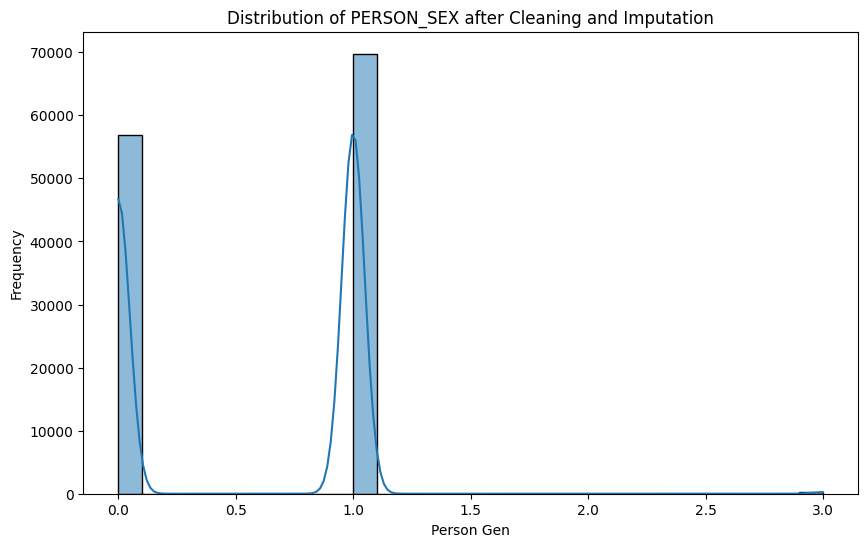

In [ ]:
# Replace erroneous age values (-997 and 9999) with NaN
drivE_sub['PERSON_SEX'] =  drivE_sub['PERSON_SEX'].replace(2, None)

# Calculate the median age, excluding NaN values
mode_gen =  drivE_sub['PERSON_SEX'].mode()[0] # Extract the scalar mode value

# Fill missing PERSON_AGE values with the calculated median
drivE_sub['PERSON_SEX'] =  drivE_sub['PERSON_SEX'].fillna(mode_gen)

# Convert PERSON_AGE to nullable integer type (Int64) to handle potential NaNs if any remained, or just int if confident no NaNs
drivE_sub['PERSON_SEX'] =  drivE_sub['PERSON_SEX'].astype('Int64')

print(f"Replaced erroneous age values and imputed missing values with median age: {mode_gen}")
print("Descriptive statistics after cleaning and imputation:")
display( drivE_sub['PERSON_SEX'].describe())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot( drivE_sub['PERSON_SEX'].dropna(), bins=30, kde=True)
plt.title('Distribution of PERSON_SEX after Cleaning and Imputation')
plt.xlabel('Person Gen')
plt.ylabel('Frequency')
plt.show()

ii :Replacing Missing items of BODILY_INJURY (16 No's) with Mode:

Replaced erroneous age values and imputed missing values with median age: 12
Descriptive statistics after cleaning and imputation:


,BODILY_INJURY
count,126973.0
mean,7.563072
std,4.368293
min,0.0
25%,4.0
50%,8.0
75%,12.0
max,14.0


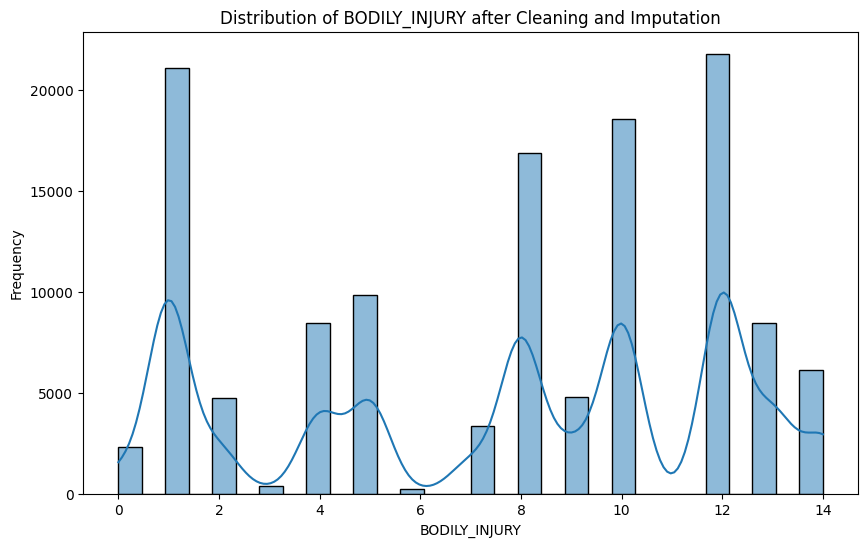

In [ ]:
# Replace erroneous age values (-997 and 9999) with NaN
drivE_sub['BODILY_INJURY'] =  drivE_sub['BODILY_INJURY'].replace(11, None)

# Calculate the median age, excluding NaN values
mode_gen =  drivE_sub['BODILY_INJURY'].mode()[0] # Extract the scalar mode value

# Fill missing PERSON_AGE values with the calculated median
drivE_sub['BODILY_INJURY'] =  drivE_sub['BODILY_INJURY'].fillna(mode_gen)

# Convert PERSON_AGE to nullable integer type (Int64) to handle potential NaNs if any remained, or just int if confident no NaNs
drivE_sub['BODILY_INJURY'] =  drivE_sub['BODILY_INJURY'].astype('Int64')

print(f"Replaced erroneous age values and imputed missing values with median age: {mode_gen}")
print("Descriptive statistics after cleaning and imputation:")
display( drivE_sub['BODILY_INJURY'].describe())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot( drivE_sub['BODILY_INJURY'].dropna(), bins=30, kde=True)
plt.title('Distribution of BODILY_INJURY after Cleaning and Imputation')
plt.xlabel('BODILY_INJURY')
plt.ylabel('Frequency')
plt.show()

iii: Replacing Missing items of EMOTIONAL_STATUS (57 No's) with Mode:

Replaced erroneous age values and imputed missing values with median age: 1
Descriptive statistics after cleaning and imputation:


,EMOTIONAL_STATUS
count,126973.0
mean,1.356785
std,1.410932
min,0.0
25%,1.0
50%,1.0
75%,1.0
max,8.0


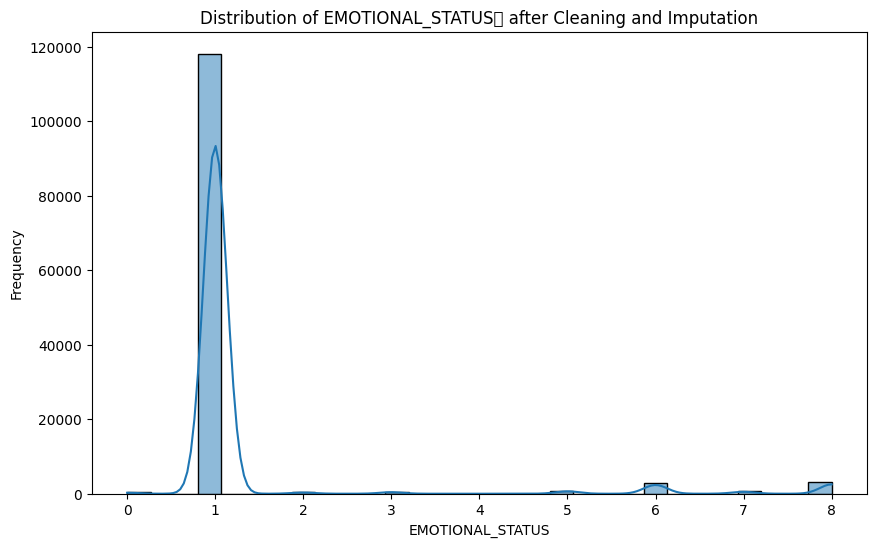

In [ ]:
# Replace erroneous age values (-997 and 9999) with NaN
drivE_sub['EMOTIONAL_STATUS'] =  drivE_sub['EMOTIONAL_STATUS'].replace(4, None)

# Calculate the median age, excluding NaN values
mode_gen =  drivE_sub['EMOTIONAL_STATUS'].mode()[0] # Extract the scalar mode value

# Fill missing PERSON_AGE values with the calculated median
drivE_sub['EMOTIONAL_STATUS'] =  drivE_sub['EMOTIONAL_STATUS'].fillna(mode_gen)

# Convert PERSON_AGE to nullable integer type (Int64) to handle potential NaNs if any remained, or just int if confident no NaNs
drivE_sub['EMOTIONAL_STATUS'] =  drivE_sub['EMOTIONAL_STATUS'].astype('Int64')

print(f"Replaced erroneous age values and imputed missing values with median age: {mode_gen}")
print("Descriptive statistics after cleaning and imputation:")
display( drivE_sub['EMOTIONAL_STATUS'].describe())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot( drivE_sub['EMOTIONAL_STATUS'].dropna(), bins=30, kde=True)
plt.title('Distribution of EMOTIONAL_STATUS\t after Cleaning and Imputation')
plt.xlabel('EMOTIONAL_STATUS')
plt.ylabel('Frequency')
plt.show()

In [ ]:
drivE_sub.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126973 entries, 0 to 230655
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   UNIQUE_ID            126973 non-null  object 
 1   COLLISION_ID         126973 non-null  float64
 2   CRASH_DATE           126973 non-null  object 
 3   CRASH_TIME           126973 non-null  object 
 4   PERSON_ID            126970 non-null  object 
 5   PERSON_TYPE          126973 non-null  int64  
 6   PERSON_INJURY        126973 non-null  object 
 7   VEHICLE_ID           100448 non-null  float64
 8   PERSON_AGE           125983 non-null  float64
 9   EJECTION             126973 non-null  int64  
 10  EMOTIONAL_STATUS     126973 non-null  Int64  
 11  BODILY_INJURY        126973 non-null  Int64  
 12  POSITION_IN_VEHICLE  126973 non-null  int64  
 13  SAFETY_EQUIPMENT     126973 non-null  int64  
 14  COMPLAINT            126973 non-null  int64  
 15  PED_ROLE             1

6.2 Filling Missing values with Prediction value using RandomForest: (for large no.of missing items)

Filling Missing Data (For features: Safety_Equipment, Position in Vehicle, Ejection)

(Important Note: filling the missing values happens only feature by feature, there are 9 steps for each feature updation, for "Safety Equipment" feature, follow steps from 1.1 to 1.9, dont run other feature steps (2.1, 3.1..) in between.) first: 1.1 to 1.9, second: 2.1 to 2.9 and third: 3.1 to 3.9

In [ ]:
# Feature=Safety Equipment (1.1)
dup1 = drivE_sub[drivE_sub['SAFETY_EQUIPMENT'] != 12]
dup12 = drivE_sub[drivE_sub['SAFETY_EQUIPMENT']==12]

In [ ]:
# Feature=POSITION_IN_VEHICLE (2.1)
dup2 = drivE_sub[drivE_sub['POSITION_IN_VEHICLE'] != 8]
dup21 = drivE_sub[drivE_sub['POSITION_IN_VEHICLE'] == 8]

In [ ]:
# Feature=EJECTION (3.1)
dup3 = drivE_sub[drivE_sub['EJECTION'] != 2]
dup31 = drivE_sub[drivE_sub['EJECTION'] == 2]

In [ ]:
dup1.shape

(90120, 20)

In [ ]:
dup31.shape

(0, 20)

In [ ]:
# Feature=Safety Equipment (1.2)
m1=dup1.drop(columns=['UNIQUE_ID','COLLISION_ID','PERSON_ID','VEHICLE_ID'],axis=1)
m12=dup12.drop(columns=['UNIQUE_ID','COLLISION_ID','PERSON_ID','VEHICLE_ID'],axis=1)

In [ ]:
# Feature=POSITION_IN_VEHICLE (2.2)
m2=dup2.drop(columns=['UNIQUE_ID','COLLISION_ID','PERSON_ID','VEHICLE_ID'],axis=1)
m21=dup21.drop(columns=['UNIQUE_ID','COLLISION_ID','PERSON_ID','VEHICLE_ID'],axis=1)

In [ ]:
# Feature=EJECTION (3.2)
m3=dup3.drop(columns=['UNIQUE_ID','COLLISION_ID','PERSON_ID','VEHICLE_ID'],axis=1)
m31=dup31.drop(columns=['UNIQUE_ID','COLLISION_ID','PERSON_ID','VEHICLE_ID'],axis=1)

In [ ]:
# Feature=Safety Equipment (1.3)
X=m1.drop(columns=['SAFETY_EQUIPMENT'],axis=1)
X1=m12.drop(columns=['SAFETY_EQUIPMENT'],axis=1)
y=m1['SAFETY_EQUIPMENT']

In [ ]:
# Feature=POSITION_IN_VEHICLE (2.3)
X=m2.drop(columns=['POSITION_IN_VEHICLE'],axis=1)
X1=m21.drop(columns=['POSITION_IN_VEHICLE'],axis=1)
y=m2['POSITION_IN_VEHICLE']


In [ ]:
# Feature=EJECTION (3.3)
X=m3.drop(columns=['EJECTION'],axis=1)
X1=m31.drop(columns=['EJECTION'],axis=1)
y=m3['EJECTION']

In [ ]:
# Applies for all features (1.4, 2.4, 3.4)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
# Applies for all features (1.5, 2.5, 3.5)

# Define the parameter grid to search
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20],
    'criterion': ['gini', 'entropy']
}

# Initialize a RandomForestClassifier model
rf_model_base = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model_base,
                            param_grid=param_grid_rf,
                            cv=2, # 5-fold cross-validation
                            n_jobs=-1, # Use all available cores
                            verbose=2, # Display progress
                            scoring='accuracy') # Metric to optimize

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

print("Grid search completed!")

Fitting 2 folds for each of 24 candidates, totalling 48 fits
Grid search completed!


In [ ]:
# Applies for all features (1.6, 2.6, 3.6)

# Make predictions on the test set
y_pred_rf = grid_search_rf.predict(X_test)


print("Predictions made successfully!")

# Evaluate the Random Forest model's performance
print("\nRandom Forest Model Evaluation:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Predictions made successfully!

Random Forest Model Evaluation:
Accuracy Score: 0.9386

Confusion Matrix:
[[  216     2   108     0     0     0]
 [    3   324   631     0     0     0]
 [   25   193 18752     0     0     0]
 [    0    54   196     1     0     0]
 [    0     0    40     0     0     0]
 [    0     1    10     0     0     2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.66      0.76       326
           1       0.56      0.34      0.42       958
           3       0.95      0.99      0.97     18970
           4       1.00      0.00      0.01       251
           5       0.00      0.00      0.00        40
           6       1.00      0.15      0.27        13

    accuracy                           0.94     20558
   macro avg       0.73      0.36      0.40     20558
weighted avg       0.93      0.94      0.93     20558



In [ ]:
# Applies for all features (1.7, 2.7, 3.7)

#Training Score

y_pred_rf1 = grid_search_rf.best_estimator_.predict(X_train)
print(f"Accuracy Score: {accuracy_score(y_train, y_pred_rf1):.4f}")

Accuracy Score: 0.9918


In [ ]:
# Applies for all features (1.8, 2.8, 3.8)

y_pred_rf = grid_search_rf.best_estimator_.predict(X1)

In [ ]:
# Applies for Safety Equipment Feature (1.9)

drivE_sub.loc[drivE_sub['SAFETY_EQUIPMENT']==12,'SAFETY_EQUIPMENT']=y_pred_rf

In [ ]:
# Applies for Position in Vehicle Feature (2.9)

drivE_sub.loc[drivE_sub['POSITION_IN_VEHICLE']==8,'POSITION_IN_VEHICLE']=y_pred_rf

ValueError: Must have equal len keys and value when setting with an iterable

In [ ]:
# Applies for Ejection Feature (3.9)

drivE_sub.loc[drivE_sub['EJECTION']==2,'EJECTION']=y_pred_rf

# 7. Model Evaluation

Creating new (caracc) Dataset - 3,as followed from the above updated record (drivE_sub):

In [ ]:
caracc=drivE_sub.drop(columns=['UNIQUE_ID', 'COLLISION_ID', 'PERSON_ID','VEHICLE_ID'],axis=1)

<Axes: >

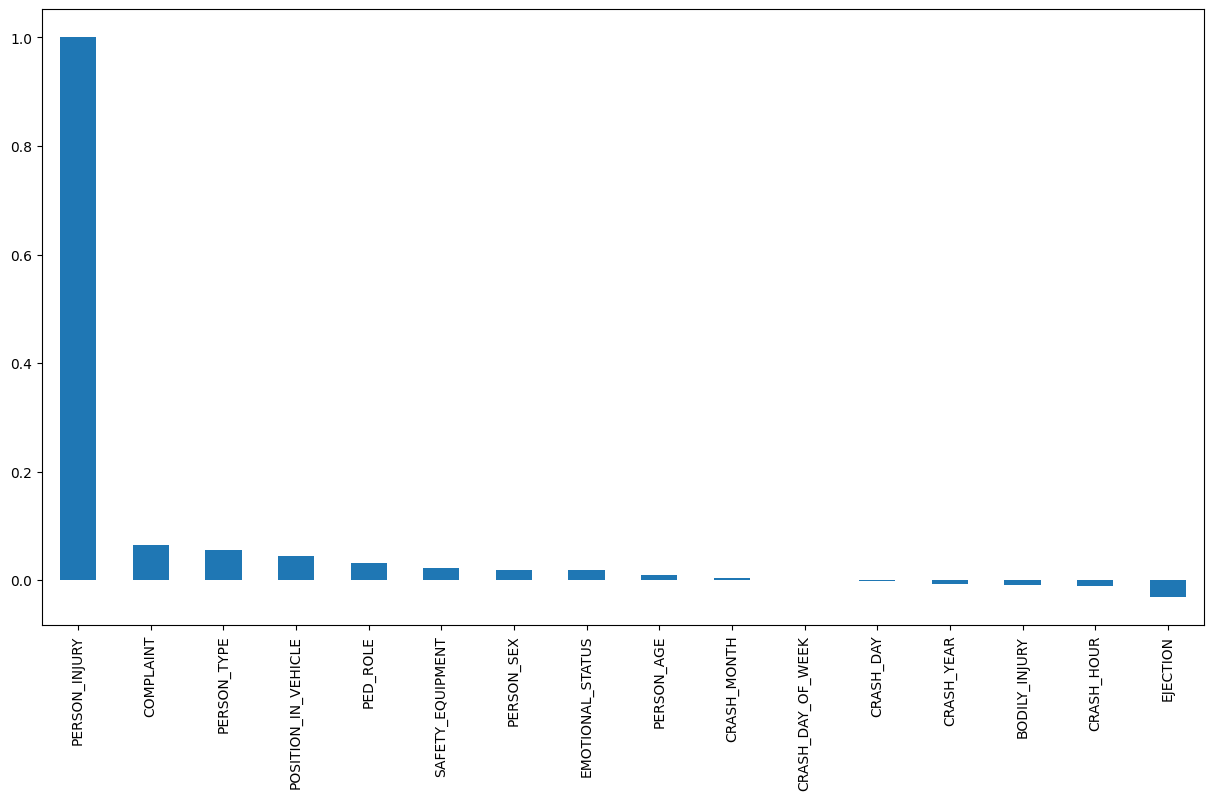

In [ ]:
plt.figure(figsize=(15,8))
caracc.corr()['PERSON_INJURY'].sort_values(ascending=False).plot(kind='bar')

In [ ]:
driv['PERSON_INJURY'].value_counts(normalize=True)*100

,proportion
PERSON_INJURY,
0,99.556482
1,0.443518


In [ ]:
caracc['PERSON_INJURY'].value_counts(normalize=True)*100

,proportion
PERSON_INJURY,
0,99.59834
1,0.40166


In [ ]:
caracc.shape

(126973, 16)

In [ ]:
caracc.head()

In [ ]:
X=caracc.drop(columns=['PERSON_INJURY'],axis=1)
y=caracc['PERSON_INJURY']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

7.1 .Random Forest

In [ ]:
# Define the parameter grid to search
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20],
    'criterion': ['gini', 'entropy']
}

# Initialize a RandomForestClassifier model
rf_model_base = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model_base,
                            param_grid=param_grid_rf,
                            cv=2, # 5-fold cross-validation
                            n_jobs=-1, # Use all available cores
                            verbose=2, # Display progress
                            scoring='accuracy') # Metric to optimize

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

print("Grid search completed!")

Fitting 2 folds for each of 24 candidates, totalling 48 fits
Grid search completed!


In [ ]:
# Make predictions on the test set
y_pred_rf = grid_search_rf.predict(X_test)


print("Predictions made successfully!")

# Evaluate the Random Forest model's performance
print("\nRandom Forest Model Evaluation:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Predictions made successfully!

Random Forest Model Evaluation:
Accuracy Score: 0.9983

Confusion Matrix:
[[25292     1]
 [   41    61]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25293
           1       0.98      0.60      0.74       102

    accuracy                           1.00     25395
   macro avg       0.99      0.80      0.87     25395
weighted avg       1.00      1.00      1.00     25395



In [ ]:
y_pred_rf1 = grid_search_rf.best_estimator_.predict(X_train)
print(f"Accuracy Score: {accuracy_score(y_train, y_pred_rf1):.4f}")

Accuracy Score: 1.0000


In [ ]:
caracc.sample(n=1)

,PERSON_TYPE,PERSON_INJURY,PERSON_AGE,EJECTION,EMOTIONAL_STATUS,BODILY_INJURY,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT,COMPLAINT,PED_ROLE,PERSON_SEX,CRASH_YEAR,CRASH_MONTH,CRASH_DAY,CRASH_DAY_OF_WEEK,CRASH_HOUR
223318,0,0,39,3,1,4,9,8,11,0,1,2017,3,12,6,12


In [ ]:
caracc.info()

7.2 .ADABoost

In [ ]:
# Initialize a base estimator (e.g., a Decision Tree)
# AdaBoost typically works well with weak learners like shallow decision trees
base_estimator = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for AdaBoost
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'estimator__max_depth': [1, 2]  # Tuning max_depth of the base_estimator
}

# Initialize the AdaBoost Classifier with a specified base estimator
# The base estimator needs to be passed to GridSearchCV, so it's defined separately.
ada_model_base = AdaBoostClassifier(estimator=base_estimator, random_state=42)

# Initialize GridSearchCV
grid_search_ada = GridSearchCV(estimator=ada_model_base,
                               param_grid=param_grid_ada,
                               cv=2, # 2-fold cross-validation
                               n_jobs=-1, # Use all available cores
                               verbose=2, # Display progress
                               scoring='accuracy') # Metric to optimize

# Fit GridSearchCV to the training data
grid_search_ada.fit(X_train, y_train)

print("Grid search for AdaBoost completed!")

In [ ]:
# Make predictions on the test set
y_pred_ada = grid_search_ada.predict(X_test)

print("Predictions made successfully!")

# Evaluate the AdaBoost model's performance
print("\nAdaBoost Model Evaluation:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_ada):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

In [ ]:
y_pred_rf1 = grid_search_ada.best_estimator_.predict(X_train)
print(f"Accuracy Score: {accuracy_score(y_train, y_pred_rf1):.4f}")

7.3 .XGBoost

In [ ]:
# Re-encode y to ensure contiguous labels after filtering
le_y = LabelEncoder()
y = le_y.fit_transform(y)

In [ ]:
# Initialize a base XGBoost Classifier
# Setting use_label_encoder=False to suppress the warning
# Setting eval_metric='logloss' for binary classification
xgb_model_base = xgb.XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', use_label_encoder=False, random_state=42, num_class=len(le_y.classes_))

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0]
}

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb_model_base,
                               param_grid=param_grid_xgb,
                               cv=2, # 2-fold cross-validation
                               n_jobs=-1, # Use all available cores
                               verbose=2, # Display progress
                               scoring='accuracy') # Metric to optimize

# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)

print("Grid search for XGBoost completed!")

# Get the best parameters and best score from GridSearchCV
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"\nBest parameters found by GridSearchCV for XGBoost: {best_params_xgb}")
print(f"Best cross-validation accuracy: {best_score_xgb:.4f}")

# Make predictions on the test set using the best estimator
y_pred_xgb = grid_search_xgb.best_estimator_.predict(X_test)

# Evaluate the tuned XGBoost model's performance
print("\nTuned XGBoost Model Evaluation (from GridSearchCV):")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Fitting 2 folds for each of 81 candidates, totalling 162 fits
Grid search for XGBoost completed!

Best parameters found by GridSearchCV for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation accuracy: 0.9985

Tuned XGBoost Model Evaluation (from GridSearchCV):
Accuracy Score: 0.9985

Confusion Matrix:
[[25288     5]
 [   34    68]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25293
           1       0.93      0.67      0.78       102

    accuracy                           1.00     25395
   macro avg       0.97      0.83      0.89     25395
weighted avg       1.00      1.00      1.00     25395



In [119]:
y_pred_rf1 = grid_search_xgb.best_estimator_.predict(X_train)
print(f"Accuracy Score: {accuracy_score(y_train, y_pred_rf1):.4f}")

Accuracy Score: 0.9986


ROC Curve and AUC for the best XGBoost model

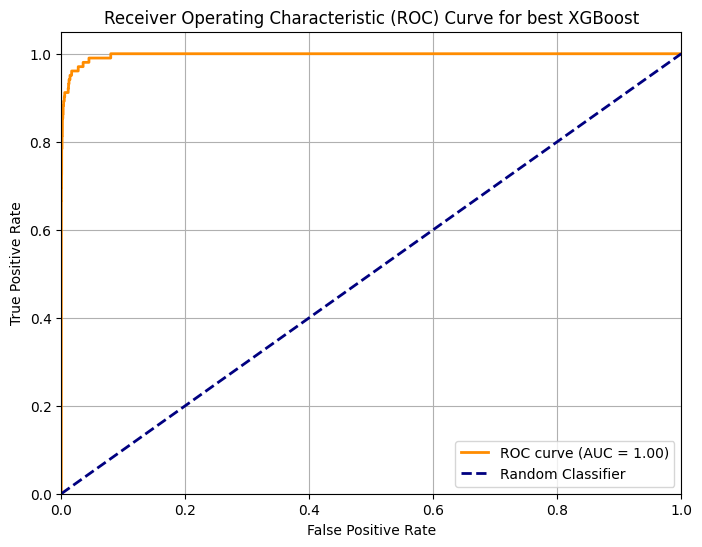

In [121]:
# --- ROC Curve and AUC for the best XGBoost model ---

# Predict probabilities for the positive class (conversion=1)
y_proba_xgb = grid_search_xgb.best_estimator_.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for best XGBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Feature Importances for XGBoost model:

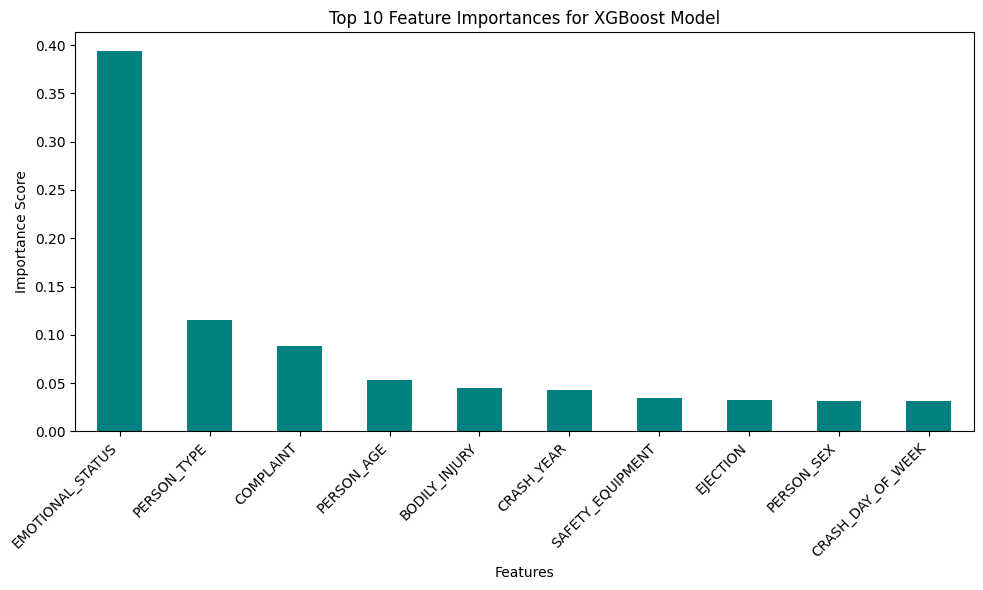

In [122]:
# To get the feature importances of all variables for XGBoost
importances = grid_search_xgb.best_estimator_.feature_importances_
weights = pd.Series(importances,
                 index=X.columns.values) # Using X1.columns as X1 was used for training xgb_model

plt.figure(figsize=(10, 6))
weights.sort_values(ascending=False).head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Feature Importances for XGBoost Model')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Applying SMOTE technique: (as we deal with imbalanced data)

In [123]:
# Before SMOTE
print(f"Original training set shape: {X_train.shape}")
print(f"Original training target distribution: {Counter(y_train)}")

# Explicitly convert y_train to a NumPy array of integers to avoid potential dtype issues with imblearn
y_train_np = y_train.astype('int64').values
X_train_np = X_train.astype('int64').values

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_np, y_train_np)

# After SMOTE
print(f"\nSMOTE training set shape: {X_train_smote.shape}")
print(f"SMOTE training target distribution: {Counter(y_train_smote)}")

Original training set shape: (101578, 15)
Original training target distribution: Counter({0: 101170, 1: 408})

SMOTE training set shape: (202340, 15)
SMOTE training target distribution: Counter({np.int64(0): 101170, np.int64(1): 101170})


7.4. XGBoost after SMOTE

In [124]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize a base XGBoost Classifier
# Setting use_label_encoder=False to suppress the warning
# Setting eval_metric='logloss' for binary classification
xgb_model_base = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0]
}

# Initialize GridSearchCV
grid_search_xgb_SM = GridSearchCV(estimator=xgb_model_base,
                               param_grid=param_grid_xgb,
                               cv=2, # 2-fold cross-validation
                               n_jobs=-1, # Use all available cores
                               verbose=2, # Display progress
                               scoring='accuracy') # Metric to optimize

# Fit GridSearchCV to the training data
grid_search_xgb_SM.fit(X_train_smote, y_train_smote)

print("Grid search for XGBoost completed!")

# Get the best parameters and best score from GridSearchCV
best_params_xgb = grid_search_xgb_SM.best_params_
best_score_xgb = grid_search_xgb_SM.best_score_

print(f"\nBest parameters found by GridSearchCV for XGBoost: {best_params_xgb}")
print(f"Best cross-validation accuracy: {best_score_xgb:.4f}")

# Make predictions on the test set using the best estimator
y_pred_xgb_tuned = grid_search_xgb_SM.best_estimator_.predict(X_test)

# Evaluate the tuned XGBoost model's performance
print("\nTuned XGBoost Model Evaluation (from GridSearchCV):")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned))

Fitting 2 folds for each of 81 candidates, totalling 162 fits
Grid search for XGBoost completed!

Best parameters found by GridSearchCV for XGBoost: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best cross-validation accuracy: 0.9981

Tuned XGBoost Model Evaluation (from GridSearchCV):
Accuracy Score: 0.9964

Confusion Matrix:
[[25230    63]
 [   29    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25293
           1       0.54      0.72      0.61       102

    accuracy                           1.00     25395
   macro avg       0.77      0.86      0.81     25395
weighted avg       1.00      1.00      1.00     25395



Receiver Operating Characteristic (ROC) Curve for Tuned XGBoost

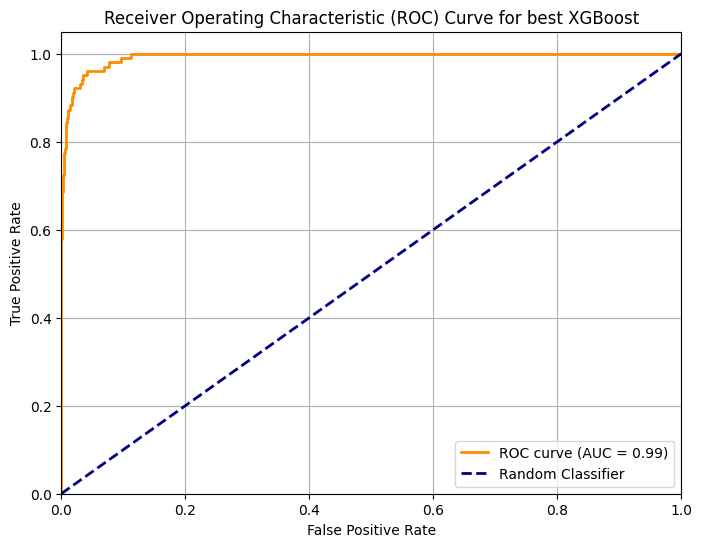

In [126]:
# --- ROC Curve and AUC for the best XGBoost model ---

# Predict probabilities for the positive class (conversion=1)
y_proba_xgb = grid_search_xgb_SM.best_estimator_.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for best XGBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Feature Importances for XGBoost after applying SMOTE:

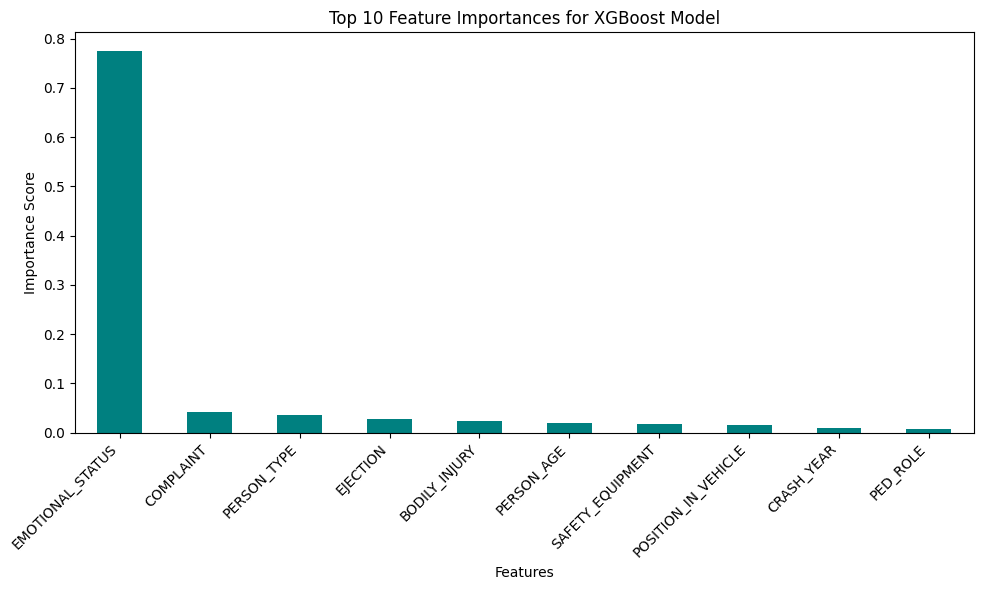

In [125]:
# To get the feature importances of all variables for XGBoost
importances = grid_search_xgb_SM.best_estimator_.feature_importances_
weights = pd.Series(importances,
                 index=X.columns.values) # Using X1.columns as X1 was used for training xgb_model

plt.figure(figsize=(10, 6))
weights.sort_values(ascending=False).head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Feature Importances for XGBoost Model')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 8.Streamlit Application

(below code can be executed in Visual Studio Code):

In [120]:
import joblib

# Save the best XGBoost model to a file
model_filename = 'xgboost_model.joblib'
joblib.dump(grid_search_xgb.best_estimator_, model_filename)

print(f"Best XGBoost model saved to {model_filename}")

Best XGBoost model saved to xgboost_model.joblib


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
from joblib import load

model=load("C:/Users/Pradeep/Downloads/xgboost_model.joblib")

model_features = [ 'PERSON_TYPE', 'PERSON_AGE', 'EJECTION',
       'EMOTIONAL_STATUS', 'BODILY_INJURY', 'POSITION_IN_VEHICLE',
       'SAFETY_EQUIPMENT', 'COMPLAINT', 'PED_ROLE', 'PERSON_SEX', 'CRASH_YEAR',
       'CRASH_MONTH', 'CRASH_DAY', 'CRASH_DAY_OF_WEEK', 'CRASH_HOUR']

st.title('Accident Severity Prediction')

st.markdown('''This app predicts whether a person will be Injured or killed''')

st.header('Information of the person who met with the accident:')


PERSON_AGE=st.number_input("Age (Years)",min_value=0,max_value=100, value=30)

PERSON_SEX=st.selectbox("Gender",['Female','Male','U'])

PED_ROLE=st.selectbox("Role",['Driver','In-Line Skater','Other','Passenger','Pedestrian'])

CRASH_YEAR=st.number_input("year",min_value=1900,max_value=2041,value=2007)

CRASH_MONTH=st.number_input("month",min_value=1,max_value=12,value=5)

CRASH_DAY=st.number_input("date",min_value=1,max_value=31,value=10)

CRASH_DAY_OF_WEEK=st.number_input("day 0-6",min_value=0,max_value=6,value=5)

CRASH_HOUR=st.number_input("hour",min_value=0,max_value=23,value=5)

COMPLAINT=st.selectbox("Complaint",['Abrasion'
    ,'Amputation'
    ,'Complaint of Pain'
    ,'Complaint of Pain or Nausea'
    ,'Concussion'
    ,'Contusion - Bruise'
    ,'Crush Injuries'
    ,'Does Not Apply'
    ,'Fracture - Dislocation'
    ,'Fracture - Distorted - Dislocation'
    ,'Internal'
    ,'Minor Bleeding'
    ,'Minor Burn'
    ,'Moderate Burn'
    ,'None Visible'
    ,'Paralysis'
    ,'Severe Bleeding'
    ,'Severe Burn'
    ,'Severe Lacerations'
    ,'Unknown'
    ,'Whiplash'])

SAFETY_EQUIPMENT=st.selectbox("Equipment",['-'
    ,'Air Bag Deployed'
    ,'Air Bag Deployed/Child Restraint'
    ,'Air Bag Deployed/Lap Belt'
    ,'Air Bag Deployed/Lap Belt/Harness'
    ,'Child Restraint Only'
    ,'Harness'
    ,'Helmet (Motorcycle Only)'
    ,'Helmet Only (In-Line Skater/Bicyclist)'
    ,'Helmet/Other (In-Line Skater/Bicyclist)'
    ,'Lap Belt'
    ,'Lap Belt & Harness'
    ,'Other'
   ,'Pads Only (In-Line Skater/Bicyclist)'
    ,'Stoppers Only (In-Line Skater/Bicyclist)'
    ,'Unknown'])

POSITION_IN_VEHICLE=st.selectbox("Position",['Any person in the rear of a station wagon, pick-up truck, all passengers on a bus, etc'
    ,'Does Not Apply'
    ,'Driver'
    ,'Front passenger, if two or more persons, including the driver, are in the front seat'
    ,'If one person is seated on another person&apos;s lap'
    ,'Left rear passenger, or rear passenger on a bicycle, motorcycle, snowmobile'
    ,'Middle front seat, or passenger lying across a seat'
    ,'Middle rear seat, or passenger lying across a seat'
    ,'Riding/Hanging on Outside'
    ,'Right rear passenger or motorcycle sidecar passenger'
    ,'Unknown'])

BODILY_INJURY=st.selectbox("Injury",['Abdomen - Pelvis'
    ,'Back'
    ,'Chest'
    ,'Does Not Apply'
    ,'Elbow-Lower-Arm-Hand'
    ,'Entire Body'
    ,'Eye'
    ,'Face'
    ,'Head'
    ,'Hip-Upper Leg'
    ,'Knee-Lower Leg Foot'
    ,'Neck'
    ,'Shoulder - Upper Arm'
    ,'Unknown'])

EMOTIONAL_STATUS=st.selectbox("Status",['Apparent Death'
    ,'Conscious'
    ,'Does Not Apply'
    ,'Incoherent'
    ,'Semiconscious'
    ,'Shock'
    ,'Unconscious'
    ,'Unknown'])

EJECTION=st.selectbox("Ejection",[ 'Does Not Apply'
    ,'Ejected'
    ,'Not Ejected'
    ,'Partially Ejected'
    ,'Trapped'
    ,'Unknown'])

PERSON_TYPE=st.selectbox("Type",['Bicyclist'
    ,'Occupant'
    ,'Other Motorized'
   ,'Pedestrian'])


input_dict={col:0 for col in model_features}

input_dict['PERSON_SEX']=PERSON_SEX
input_dict['PERSON_TYPE']=PERSON_TYPE
input_dict['PERSON_AGE']=PERSON_AGE
input_dict['EJECTION']=EJECTION
input_dict['EMOTIONAL_STATUS']=EMOTIONAL_STATUS
input_dict['BODILY_INJURY']=BODILY_INJURY
input_dict['POSITION_IN_VEHICLE']=POSITION_IN_VEHICLE
input_dict['SAFETY_EQUIPMENT']=SAFETY_EQUIPMENT
input_dict['COMPLAINT']=COMPLAINT
input_dict['PED_ROLE']=PED_ROLE
input_dict['CRASH_YEAR']=CRASH_YEAR
input_dict['CRASH_MONTH']=CRASH_MONTH
input_dict['CRASH_DAY']=CRASH_DAY
input_dict['CRASH_DAY_OF_WEEK']=CRASH_DAY_OF_WEEK
input_dict['CRASH_HOUR']=CRASH_HOUR



if PERSON_SEX == 'Male':
  input_dict['PERSON_SEX']=1
elif PERSON_SEX == 'Female':
  input_dict['PERSON_SEX']=0
else:
  input_dict['PERSON_SEX']=3

if PED_ROLE == 'Driver':
  input_dict['PED_ROLE']=0
elif PED_ROLE == 'In-Line Skater':
  input_dict['PED_ROLE']=1
elif PED_ROLE == 'other':
  input_dict['PED_ROLE']=2
elif PED_ROLE == 'Passenger':
  input_dict['PED_ROLE']=3
else:
  input_dict['PED_ROLE']=4

if COMPLAINT == 'Abrasion':
  input_dict['COMPLAINT']=0
elif COMPLAINT == 'Amputation':
  input_dict['COMPLAINT']=1
elif COMPLAINT == 'Complaint of Pain':
  input_dict['COMPLAINT']=2
elif COMPLAINT == 'Complaint of Pain or Nausea':
  input_dict['COMPLAINT']=3
elif COMPLAINT == 'Concussion':
  input_dict['COMPLAINT']=4
elif COMPLAINT == 'Contusion - Bruise:':
  input_dict['COMPLAINT']=5
elif COMPLAINT == 'Crush Injuries':
  input_dict['COMPLAINT']=6
elif COMPLAINT == 'Does Not Apply':
  input_dict['COMPLAINT']=7
elif COMPLAINT == 'Fracture - Dislocation':
  input_dict['COMPLAINT']=8
elif COMPLAINT == 'Fracture - Distorted - Dislocation':
  input_dict['COMPLAINT']=9
elif COMPLAINT == 'Internal':
  input_dict['COMPLAINT']=10
elif COMPLAINT == 'Minor Bleeding':
  input_dict['COMPLAINT']=11
elif COMPLAINT == 'Minor Burn':
  input_dict['COMPLAINT']=12
elif COMPLAINT == 'Moderate Burn':
  input_dict['COMPLAINT']=13
elif COMPLAINT == 'None Visible':
  input_dict['COMPLAINT']=14
elif COMPLAINT == 'Paralysis':
  input_dict['COMPLAINT']=15
elif COMPLAINT == 'Severe Bleeding':
  input_dict['COMPLAINT']=16
elif COMPLAINT == 'Severe Burn':
  input_dict['COMPLAINT']=17
elif COMPLAINT == 'Severe Lacerations':
  input_dict['COMPLAINT']=18
elif COMPLAINT == 'Unknown':
  input_dict['COMPLAINT']=19
else:
  input_dict['COMPLAINT']=20

if SAFETY_EQUIPMENT == 'Air Bag Deployed':
  input_dict['SAFETY_EQUIPMENT']=1
elif SAFETY_EQUIPMENT == 'Air Bag Deployed/Child Restraint':
  input_dict['SAFETY_EQUIPMENT']=2
elif SAFETY_EQUIPMENT == 'Air Bag Deployed/Lap Belt':
  input_dict['SAFETY_EQUIPMENT']=3
elif SAFETY_EQUIPMENT == 'Air Bag Deployed/Lap Belt/Harness':
  input_dict['SAFETY_EQUIPMENT']=4
elif SAFETY_EQUIPMENT == 'Child Restraint Only':
  input_dict['SAFETY_EQUIPMENT']=5
elif SAFETY_EQUIPMENT == 'Harness':
  input_dict['SAFETY_EQUIPMENT']=6
elif SAFETY_EQUIPMENT == 'Helmet (Motorcycle Only)':
  input_dict['SAFETY_EQUIPMENT']=7
elif SAFETY_EQUIPMENT == 'Helmet Only (In-Line Skater/Bicyclist)':
  input_dict['SAFETY_EQUIPMENT']=8
elif SAFETY_EQUIPMENT == 'Helmet/Other (In-Line Skater/Bicyclist)':
  input_dict['SAFETY_EQUIPMENT']=9
elif SAFETY_EQUIPMENT == 'Lap Belt':
  input_dict['SAFETY_EQUIPMENT']=10
elif SAFETY_EQUIPMENT == 'Lap Belt & Harness':
  input_dict['SAFETY_EQUIPMENT']=11
elif SAFETY_EQUIPMENT == 'Other:':
  input_dict['SAFETY_EQUIPMENT']=13
elif SAFETY_EQUIPMENT == 'Pads Only (In-Line Skater/Bicyclist)':
  input_dict['SAFETY_EQUIPMENT']=14
elif SAFETY_EQUIPMENT == 'Stoppers Only (In-Line Skater/Bicyclist)':
  input_dict['SAFETY_EQUIPMENT']=15
elif SAFETY_EQUIPMENT == 'Unknown':
  input_dict['SAFETY_EQUIPMENT']=16
else:
  input_dict['SAFETY_EQUIPMENT']=0



if POSITION_IN_VEHICLE == 'Any person in the rear of a station wagon, pick-up truck, all passengers on a bus, etc':
  input_dict['POSITION_IN_VEHICLE']=0
elif POSITION_IN_VEHICLE == 'Does Not Apply':
  input_dict['POSITION_IN_VEHICLE']=1
elif POSITION_IN_VEHICLE == 'Driver':
  input_dict['POSITION_IN_VEHICLE']=2
elif POSITION_IN_VEHICLE == 'Front passenger, if two or more persons, including the driver, are in the front seat':
  input_dict['POSITION_IN_VEHICLE']=3
elif POSITION_IN_VEHICLE == 'If one person is seated on another person&apos;s lap':
  input_dict['POSITION_IN_VEHICLE']=4
elif POSITION_IN_VEHICLE == 'Left rear passenger, or rear passenger on a bicycle, motorcycle, snowmobile':
  input_dict['POSITION_IN_VEHICLE']=5
elif POSITION_IN_VEHICLE == 'Middle front seat, or passenger lying across a seat':
  input_dict['POSITION_IN_VEHICLE']=6
elif POSITION_IN_VEHICLE == 'Middle rear seat, or passenger lying across a seat':
  input_dict['POSITION_IN_VEHICLE']=7
elif POSITION_IN_VEHICLE == 'Riding/Hanging on Outside':
  input_dict['POSITION_IN_VEHICLE']=9
elif POSITION_IN_VEHICLE == 'Right rear passenger or motorcycle sidecar passenger':
  input_dict['POSITION_IN_VEHICLE']=10
else:
  input_dict['POSITION_IN_VEHICLE']=11

if BODILY_INJURY == 'Abdomen - Pelvis':
  input_dict['BODILY_INJURY']=0
elif BODILY_INJURY == 'Back':
  input_dict['BODILY_INJURY']=1
elif BODILY_INJURY == 'Chest':
  input_dict['BODILY_INJURY']=2
elif BODILY_INJURY == 'Does Not Apply':
  input_dict['BODILY_INJURY']=3
elif BODILY_INJURY == 'Elbow-Lower-Arm-Hand':
  input_dict['BODILY_INJURY']=4
elif BODILY_INJURY == 'Entire Body':
  input_dict['BODILY_INJURY']=5
elif BODILY_INJURY == ' Eye':
  input_dict['BODILY_INJURY']=6
elif BODILY_INJURY == 'Face':
  input_dict['BODILY_INJURY']=7
elif BODILY_INJURY == 'Head':
  input_dict['BODILY_INJURY']=8
elif BODILY_INJURY == 'Hip-Upper Leg':
  input_dict['BODILY_INJURY']=9
elif BODILY_INJURY == 'Knee-Lower Leg Foot':
  input_dict['BODILY_INJURY']=10
elif BODILY_INJURY == 'Neck':
  input_dict['BODILY_INJURY']=12
elif BODILY_INJURY == 'Shoulder - Upper Arm':
  input_dict['BODILY_INJURY']=13
else:
  input_dict['BODILY_INJURY']=14

if EMOTIONAL_STATUS == 'Apparent Death':
  input_dict['EMOTIONAL_STATUS']=0
elif EMOTIONAL_STATUS == 'Conscious':
  input_dict['EMOTIONAL_STATUS']=1
elif EMOTIONAL_STATUS == 'Does Not Apply':
  input_dict['EMOTIONAL_STATUS']=2
elif EMOTIONAL_STATUS == 'Incoherent':
  input_dict['EMOTIONAL_STATUS']=3
elif EMOTIONAL_STATUS == 'Semiconscious':
  input_dict['EMOTIONAL_STATUS']=5
elif EMOTIONAL_STATUS == 'Shock':
  input_dict['EMOTIONAL_STATUS']=6
elif EMOTIONAL_STATUS == ' Unconscious':
  input_dict['EMOTIONAL_STATUS']=7
else:
  input_dict['EMOTIONAL_STATUS']=8

if EJECTION == 'Does Not Apply':
  input_dict['EJECTION']=0
elif EJECTION == 'Ejected':
  input_dict['EJECTION']=1
elif EJECTION == 'Not Ejected':
  input_dict['EJECTION']=3
elif EJECTION == 'Partially Ejected':
  input_dict['EJECTION']=4
elif EJECTION == 'Trapped':
  input_dict['EJECTION']=5
else:
  input_dict['EJECTION']=6


if PERSON_TYPE == 'Bicyclist':
  input_dict['PERSON_TYPE']=0
elif PERSON_TYPE == 'Occupant':
  input_dict['PERSON_TYPE']=1
elif PERSON_TYPE == 'Other Motorized':
  input_dict['PERSON_TYPE']=2
else:
  input_dict['PERSON_TYPE']=3


input_df=pd.DataFrame([input_dict])

if st.button('Predict Accident Severity'):
  prediction=model.predict(input_df)
  proba=model.predict_proba(input_df)[:, 1]

  st.header('Prediction Result')
  if prediction[0] == 1:
            st.success(f'The person is killed. (Probability: {proba[0]:.2f})')
  else:
            st.warning(f'The person is injured. (Probability: {1-proba[0]:.2f})')

  st.write('Submitted Data (Processed for Prediction):')
  st.dataframe(input_df)

9. Conclusion:
The XGBoost model, without applying SMOTE, emerged as the most suitable model for this dataset with consideration of Precision, Recall and F1-Score for the minority class (1-Death).

Excellent Performance for the Majority Class (Injured/Class 0): The model performs almost perfectly for predicting 'Injured' cases, with a precision, recall, and F1-score of 1.00. This is largely due to the overwhelming number of 'Injured' instances.
Good Precision for the Minority Class (Death/Class 1): When the model predicts 'Death', it is correct 93% of the time (Precision = 0.93).